In [1]:
# Deep Learning Lab-1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import os
os.makedirs("plots", exist_ok=True)

In [2]:
#Task1: Data Exploration
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication.txt


In [3]:
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv("data_banknote_authentication.txt", header=None, names=column_names)

In [4]:
# Display first five records

print("First Five Records:")
df.head()

First Five Records:


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
print("Dataset Shape:")
print(df.shape)

print(f"\nNumber of Samples : {df.shape[0]}")
print(f"Number of Features: {df.shape[1]-1}")

Dataset Shape:
(1372, 5)

Number of Samples : 1372
Number of Features: 4


In [6]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [7]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [8]:
print("Statistical Summary:\n")
df.describe()

Statistical Summary:



,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [9]:
print("Class Distribution:\n")
print(df["Class"].value_counts())

Class Distribution:

Class
0    762
1    610
Name: count, dtype: int64


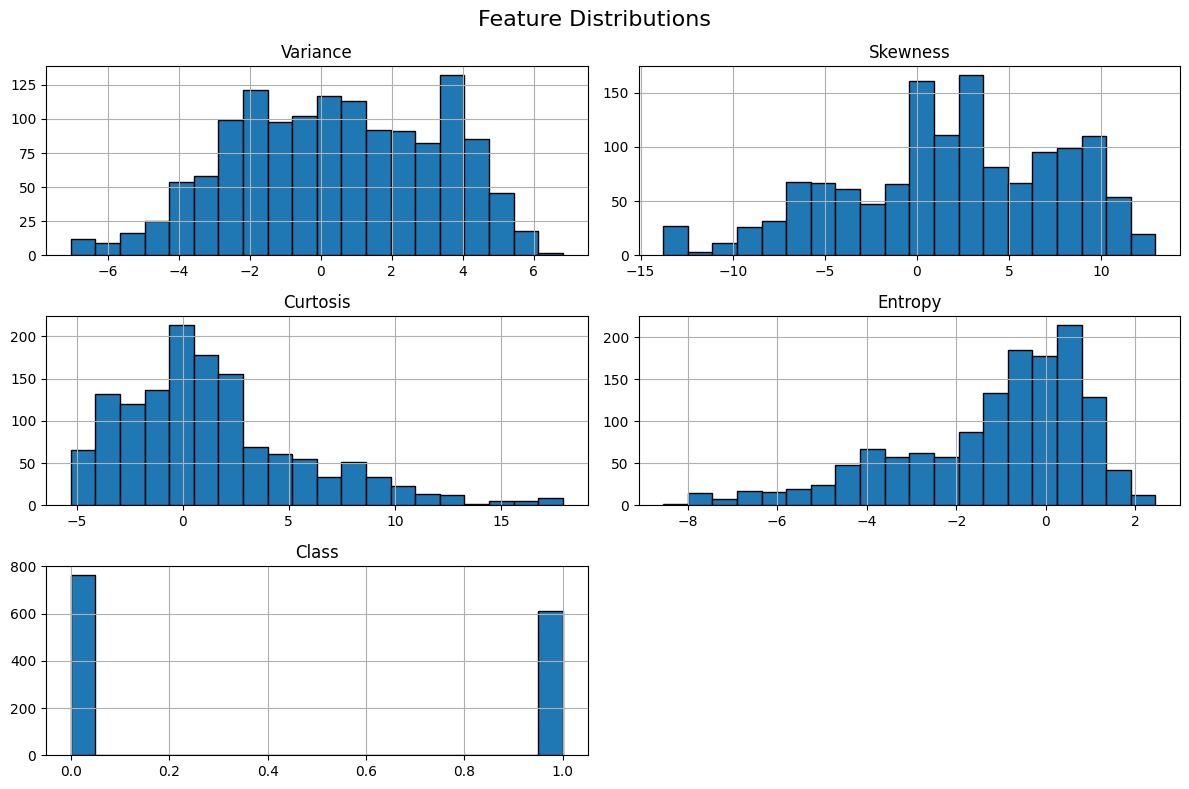

In [10]:
# Task2: EDA
#Histograms

df.hist(figsize=(12,8), bins=20, edgecolor='black')

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(
    "Histogram.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

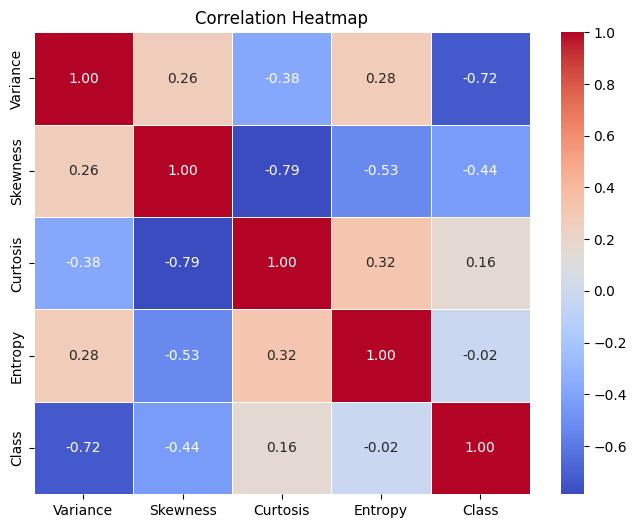

In [11]:
#Heatmaps
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("heatmap.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

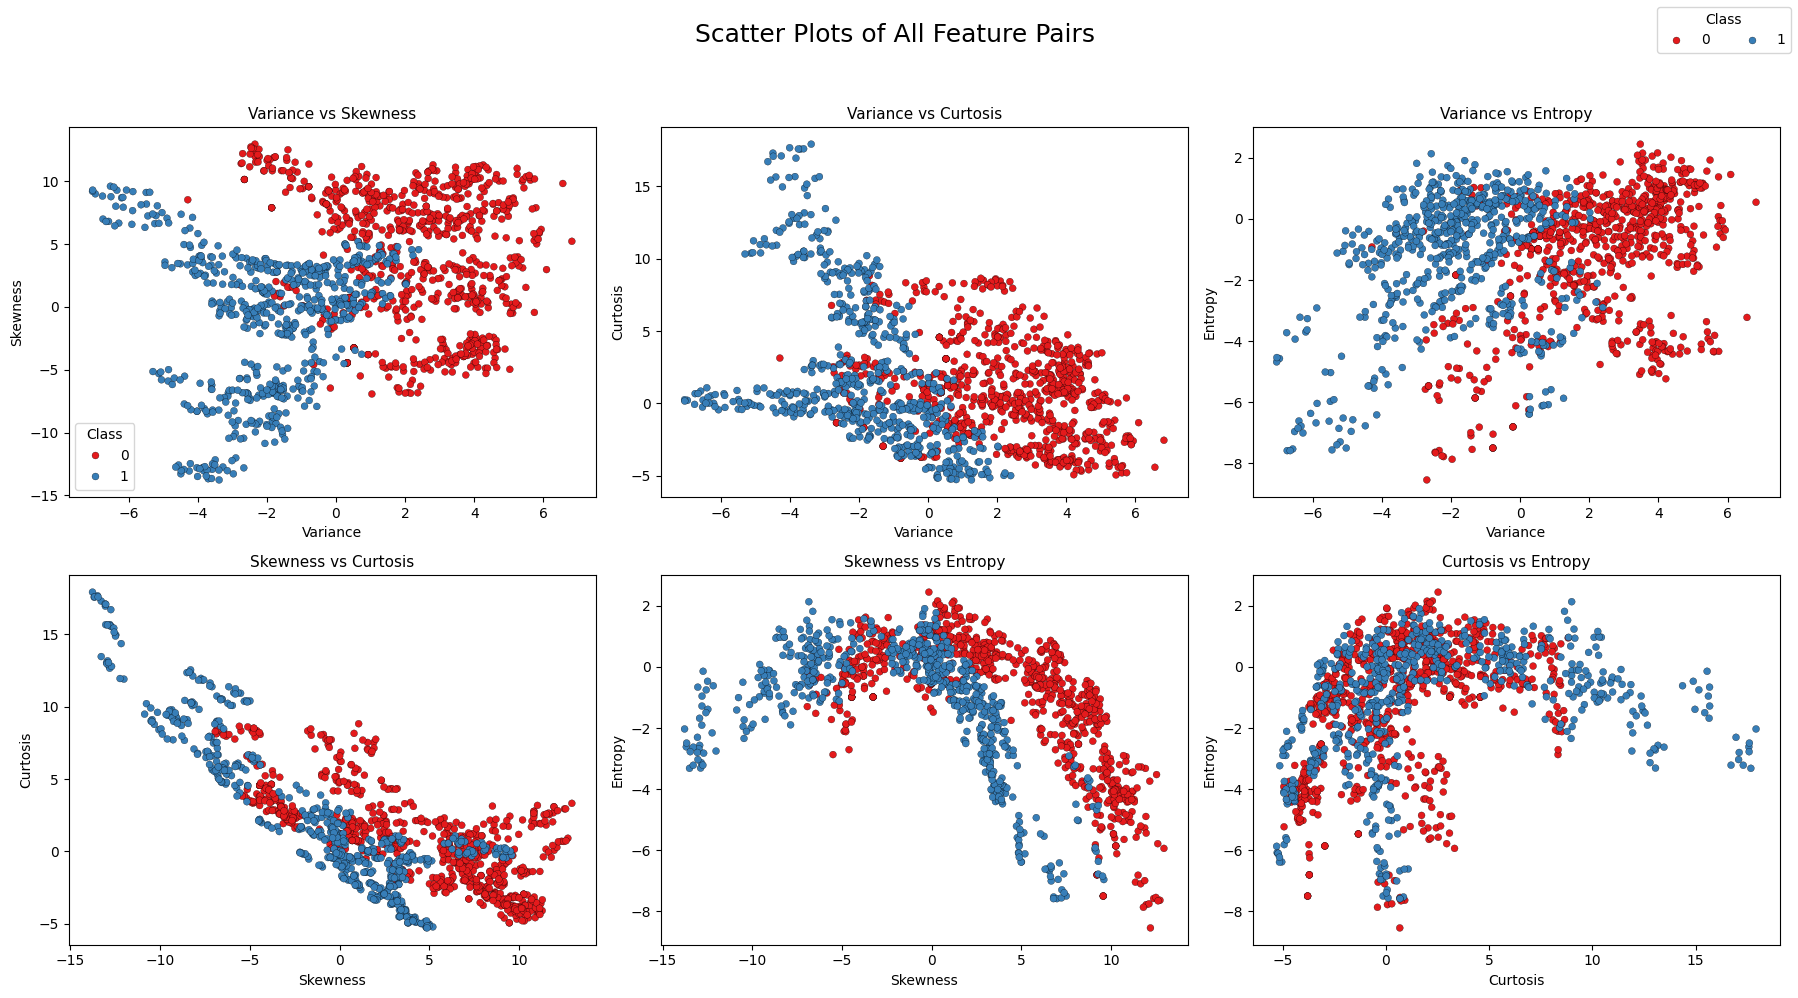

In [12]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

# All possible feature pairs
pairs = list(itertools.combinations(features, 2))

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (x_feature, y_feature) in zip(axes.flatten(), pairs):

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue='Class',
        palette='Set1',
        ax=ax,
        s=25,
        edgecolor='black',
        linewidth=0.2
    )

    ax.set_title(f"{x_feature} vs {y_feature}", fontsize=11)

    # Show legend only in the first subplot
    if ax != axes.flatten()[0]:
        ax.get_legend().remove()

# Common legend
handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title="Class",
           loc="upper right",
           ncol=2,
           fontsize=10)

plt.suptitle("Scatter Plots of All Feature Pairs", fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "scatter_plots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

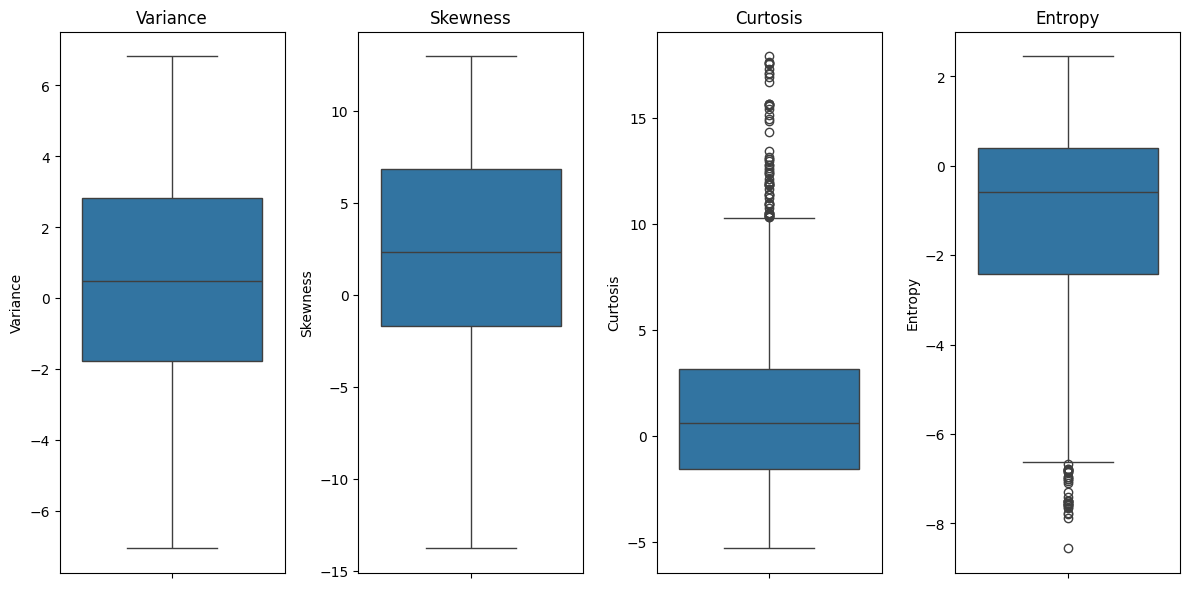

In [13]:
#Box Plots
plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.savefig("boxplot.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

In [14]:
#Data preprocessing
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1372, 4)
Target Shape   : (1372,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [71]:
# Single Layer Perceptron from Scratch

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

        # Store training history
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    # Step Activation Function
    def activation(self, x):
        return 1 if x >= 0 else 0

    # Train the Perceptron
    def fit(self, X, y):

        # Initialize weights and bias
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        # Training Loop
        for epoch in range(self.epochs):

            errors = 0

            for x_i, target in zip(X, y):

                # Forward Propagation
                linear_output = np.dot(x_i, self.weights) + self.bias

                # Prediction
                prediction = self.activation(linear_output)

                # Calculate Error
                error = target - prediction

                # Update weights and bias if prediction is incorrect
                if error != 0:

                    self.weights += self.learning_rate * error * x_i
                    self.bias += self.learning_rate * error
                    if X.shape[1] == 2:
                      self.plot_decision_boundary(
                          X,
                          y,
                          title=f"Epoch {epoch+1} | Update"
                          )
                      print(f"Updated Weights: {self.weights}")
                      print(f"Updated Bias   : {self.bias}")

                      self.weight_history.append(self.weights.copy())
                      self.bias_history.append(self.bias)
                    errors += 1

            # Save history
            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            # Print epoch information
            print(f"Epoch {epoch+1:2d}/{self.epochs}")
            print(f"Misclassified Samples : {errors}")
            print(f"Weights : {self.weights}")
            print(f"Bias    : {self.bias}")
            print("-"*50)

            # Stop if perfectly classified
            if errors == 0:
                print("Training converged successfully!")
                break

    # Predict Single Sample
    def predict_sample(self, x):

        linear_output = np.dot(x, self.weights) + self.bias

        return self.activation(linear_output)

    # Predict Multiple Samples
    def predict(self, X):

        predictions = []

        for x in X:
            predictions.append(self.predict_sample(x))

        return np.array(predictions)

    def plot_decision_boundary(self, X, y, title="Decision Boundary"):

      plt.figure(figsize=(5,5))

      # Plot data points
      for label in np.unique(y):
          plt.scatter(
              X[y == label][:,0],
              X[y == label][:,1],
              label=f"Class {label}",
              s=100
          )

      # Plot decision boundary
      x_values = np.linspace(-0.5, 1.5, 100)

      if self.weights[1] != 0:
          y_values = -(self.weights[0] * x_values + self.bias) / self.weights[1]
          plt.plot(x_values, y_values, 'k-', linewidth=2)

      plt.xlim(-0.5, 1.5)
      plt.ylim(-0.5, 1.5)

      plt.grid(True)
      plt.legend()
      plt.title(title)
      plt.show()

In [52]:
#Model Training
# Create Perceptron Object
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=50
)

perceptron.fit(X_train, y_train)

Epoch  1/50
Misclassified Samples : 47
Weights : [-0.06920384 -0.06634441 -0.06529563 -0.00524322]
Bias    : -0.03
--------------------------------------------------
Epoch  2/50
Misclassified Samples : 22
Weights : [-0.07576842 -0.09439477 -0.05170347 -0.00312988]
Bias    : -0.03
--------------------------------------------------
Epoch  3/50
Misclassified Samples : 28
Weights : [-0.08628609 -0.10389484 -0.06133036 -0.00617938]
Bias    : -0.03
--------------------------------------------------
Epoch  4/50
Misclassified Samples : 24
Weights : [-0.09820347 -0.0939408  -0.08818487 -0.01037106]
Bias    : -0.05
--------------------------------------------------
Epoch  5/50
Misclassified Samples : 29
Weights : [-0.10984895 -0.12095156 -0.08618021  0.0003308 ]
Bias    : -0.04
--------------------------------------------------
Epoch  6/50
Misclassified Samples : 17
Weights : [-0.10385459 -0.13004831 -0.08702307  0.01372732]
Bias    : -0.05
--------------------------------------------------
Epoc

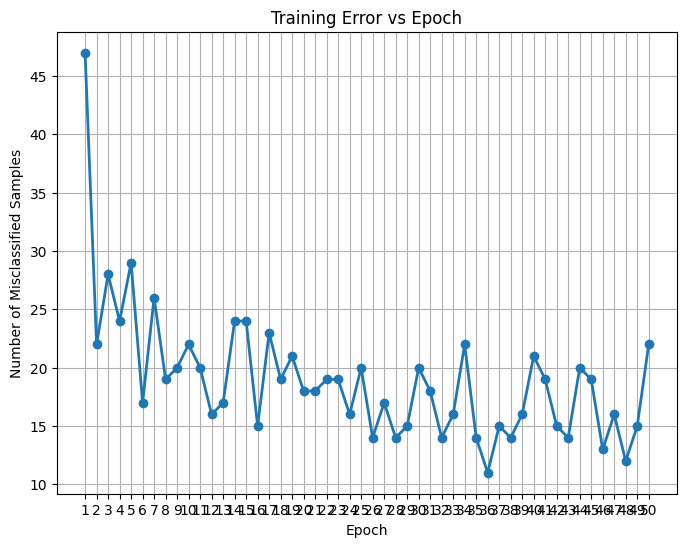

In [53]:
# Training Error vs Epoch

plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(perceptron.errors) + 1),
    perceptron.errors,
    marker='o',
    linewidth=2,
    markersize=6
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")

plt.xticks(range(1, len(perceptron.errors) + 1))
plt.grid(True)

plt.savefig(
    "training_error.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

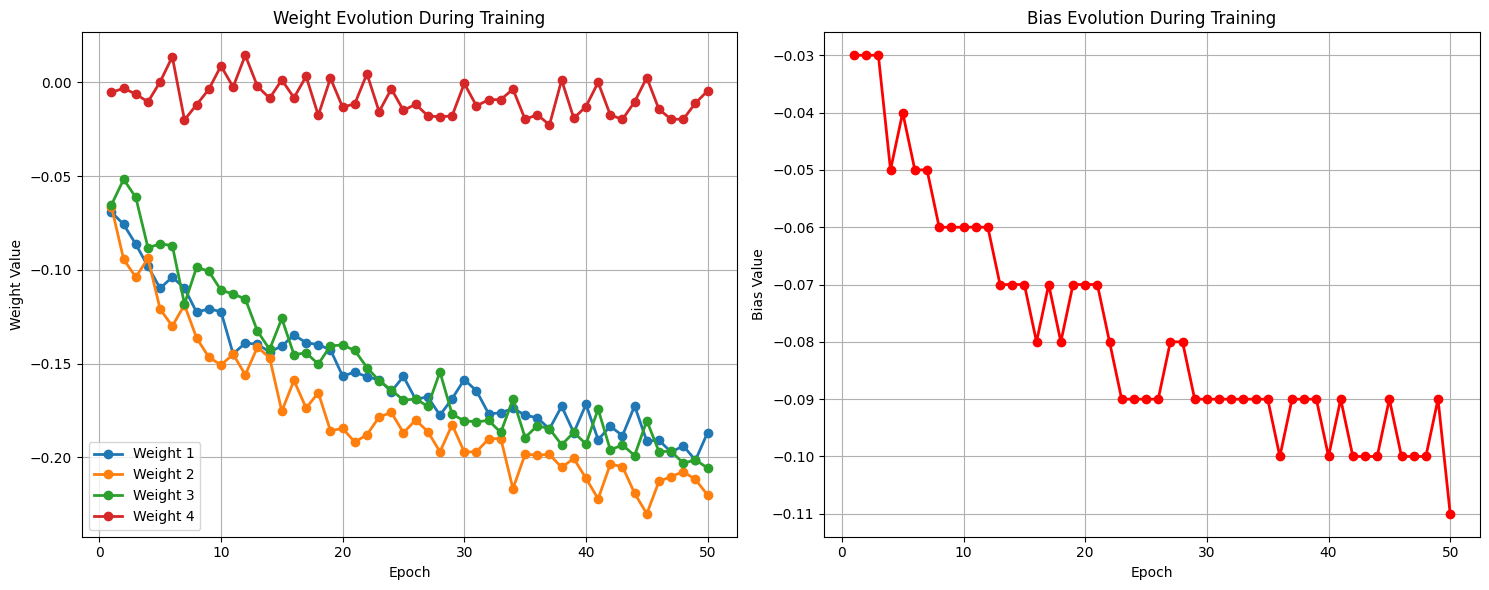

In [54]:
# Convert weight history to NumPy array
weight_history = np.array(perceptron.weight_history)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------- Weight Evolution --------------------
for i in range(weight_history.shape[1]):
    axes[0].plot(
        range(1, len(weight_history) + 1),
        weight_history[:, i],
        marker='o',
        linewidth=2,
        label=f'Weight {i+1}'
    )

axes[0].set_title("Weight Evolution During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weight Value")
axes[0].grid(True)
axes[0].legend()

# -------------------- Bias Evolution --------------------
axes[1].plot(
    range(1, len(perceptron.bias_history) + 1),
    perceptron.bias_history,
    marker='o',
    linewidth=2,
    color='red'
)

axes[1].set_title("Bias Evolution During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Bias Value")
axes[1].grid(True)

# Adjust spacing
plt.tight_layout()

# Save as EPS
plt.savefig(
    "weights_bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [55]:
#Model Prediction
y_pred = perceptron.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nActual Labels:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

Actual Labels:
[0 0 0 0 0 0 0 0 0 0]


In [56]:
#Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*40)
print("Model Evaluation")
print("="*40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Evaluation
Accuracy : 0.9818
Precision: 1.0000
Recall   : 0.9606
F1-Score : 0.9799


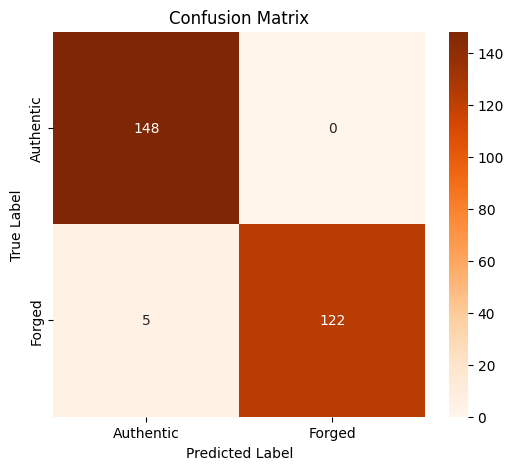

In [57]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Authentic", "Forged"],
    yticklabels=["Authentic", "Forged"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("ConfusionMatrix.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

Epoch  1/50
Misclassified Samples : 47
Weights : [-0.00692038 -0.00663444 -0.00652956 -0.00052432]
Bias    : -0.003
--------------------------------------------------
Epoch  2/50
Misclassified Samples : 22
Weights : [-0.00757684 -0.00943948 -0.00517035 -0.00031299]
Bias    : -0.003
--------------------------------------------------
Epoch  3/50
Misclassified Samples : 28
Weights : [-0.00862861 -0.01038948 -0.00613304 -0.00061794]
Bias    : -0.003
--------------------------------------------------
Epoch  4/50
Misclassified Samples : 24
Weights : [-0.00982035 -0.00939408 -0.00881849 -0.00103711]
Bias    : -0.005
--------------------------------------------------
Epoch  5/50
Misclassified Samples : 29
Weights : [-1.09848954e-02 -1.20951565e-02 -8.61802072e-03  3.30799957e-05]
Bias    : -0.004
--------------------------------------------------
Epoch  6/50
Misclassified Samples : 17
Weights : [-0.01038546 -0.01300483 -0.00870231  0.00137273]
Bias    : -0.005
---------------------------------

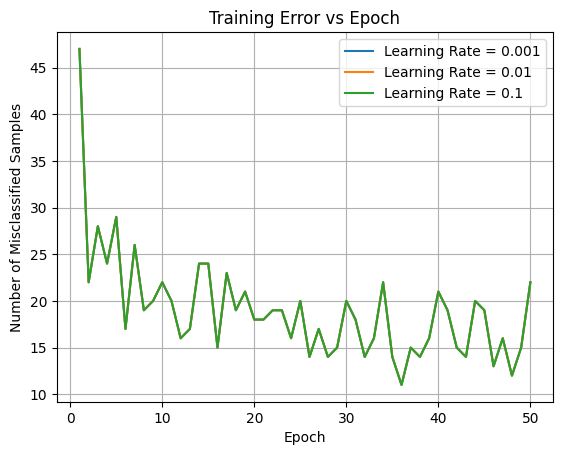

In [58]:
# Learning rates to compare
learning_rates = [0.001, 0.01, 0.1]

# Training Error vs Epoch
for lr in learning_rates:

    perceptron = Perceptron(
        learning_rate=lr,
        epochs=50
    )

    perceptron.fit(X_train, y_train)
    plt.plot(
        range(1, len(perceptron.errors) + 1),
        perceptron.errors,
        label=f"Learning Rate = {lr}"
    )
    print("="*50)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.legend()
plt.grid(True)

plt.savefig(
    "learning_rate_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()



In [59]:
import shutil

shutil.make_archive(
    "plots",
    "zip",
    "plots"
)

'/content/plots.zip'

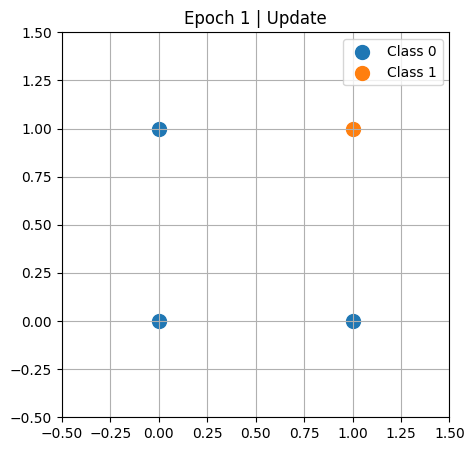

Updated Weights: [0. 0.]
Updated Bias   : -0.01


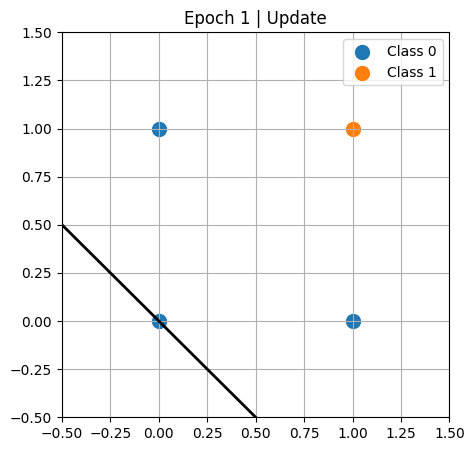

Updated Weights: [0.01 0.01]
Updated Bias   : 0.0
Epoch  1/20
Misclassified Samples : 2
Weights : [0.01 0.01]
Bias    : 0.0
--------------------------------------------------


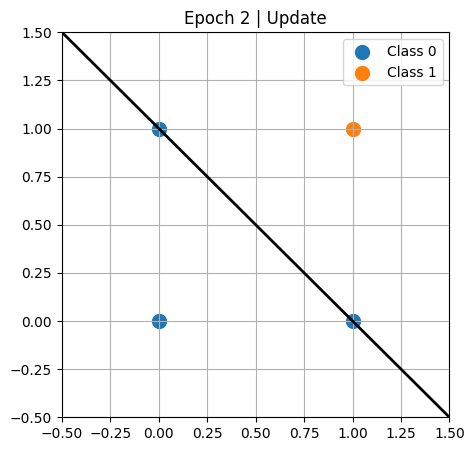

Updated Weights: [0.01 0.01]
Updated Bias   : -0.01


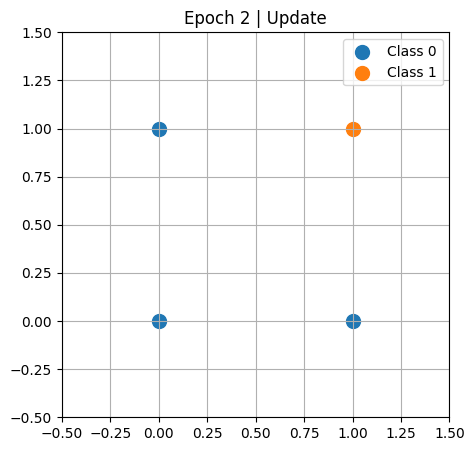

Updated Weights: [0.01 0.  ]
Updated Bias   : -0.02


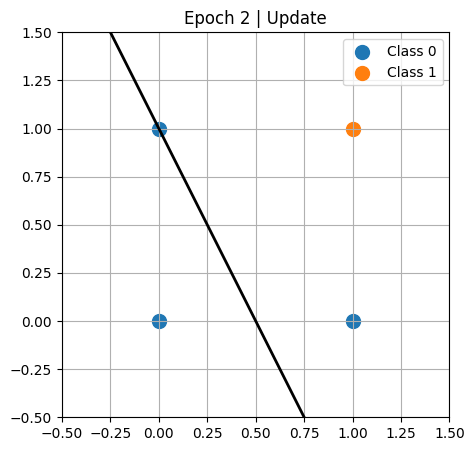

Updated Weights: [0.02 0.01]
Updated Bias   : -0.01
Epoch  2/20
Misclassified Samples : 3
Weights : [0.02 0.01]
Bias    : -0.01
--------------------------------------------------


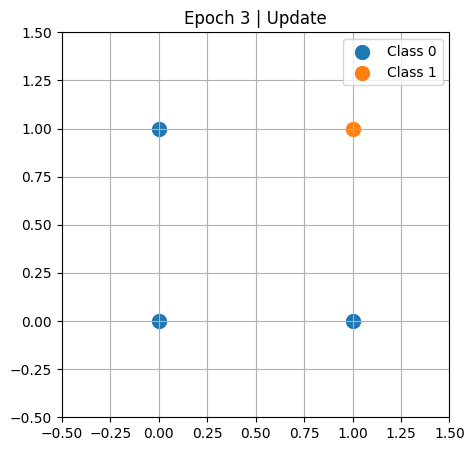

Updated Weights: [0.02 0.  ]
Updated Bias   : -0.02


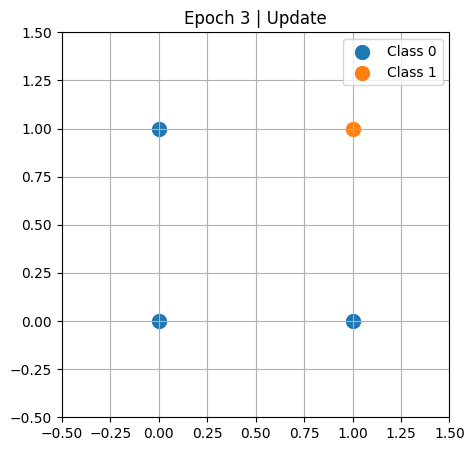

Updated Weights: [0.01 0.  ]
Updated Bias   : -0.03


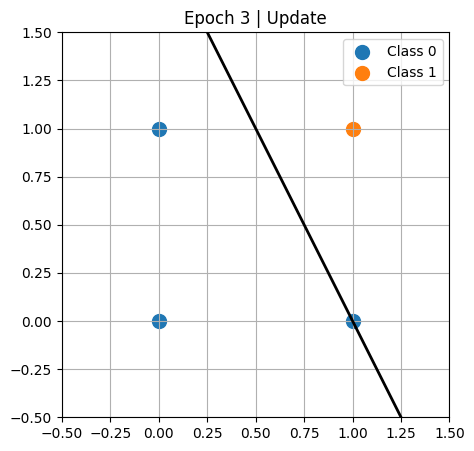

Updated Weights: [0.02 0.01]
Updated Bias   : -0.019999999999999997
Epoch  3/20
Misclassified Samples : 3
Weights : [0.02 0.01]
Bias    : -0.019999999999999997
--------------------------------------------------


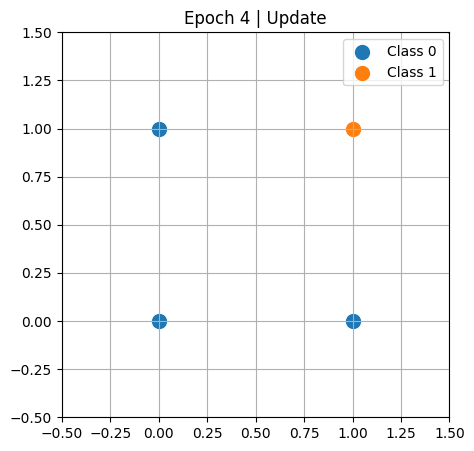

Updated Weights: [0.01 0.01]
Updated Bias   : -0.03


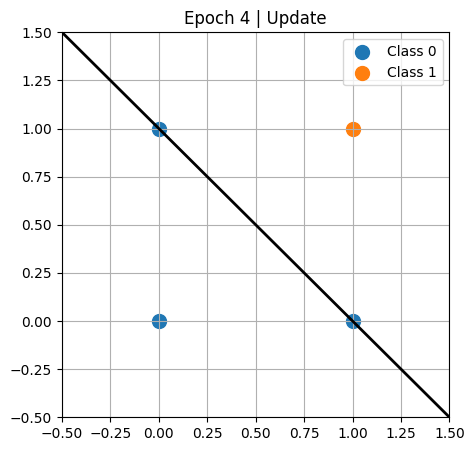

Updated Weights: [0.02 0.02]
Updated Bias   : -0.019999999999999997
Epoch  4/20
Misclassified Samples : 2
Weights : [0.02 0.02]
Bias    : -0.019999999999999997
--------------------------------------------------


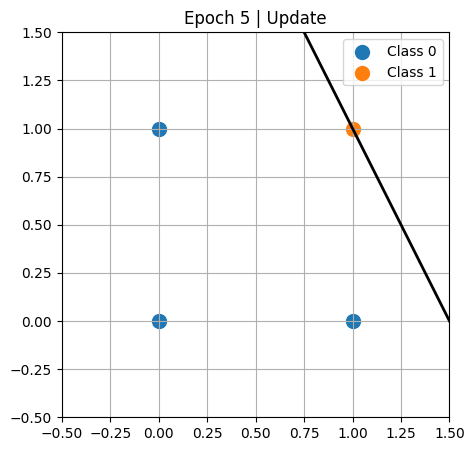

Updated Weights: [0.02 0.01]
Updated Bias   : -0.03
Epoch  5/20
Misclassified Samples : 1
Weights : [0.02 0.01]
Bias    : -0.03
--------------------------------------------------
Epoch  6/20
Misclassified Samples : 0
Weights : [0.02 0.01]
Bias    : -0.03
--------------------------------------------------
Training converged successfully!


In [62]:
#Perceptron for AND Gate
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

perceptron = Perceptron(learning_rate=0.01, epochs=20)
perceptron.fit(X, y)

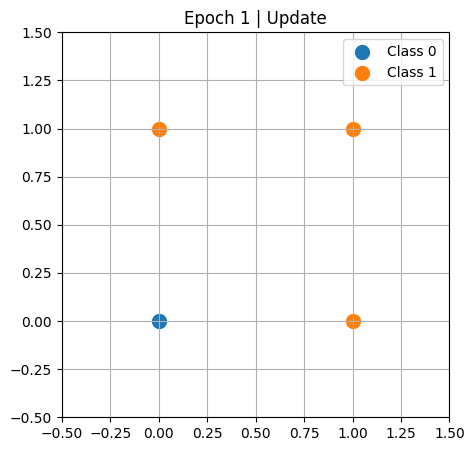

Updated Weights: [0. 0.]
Updated Bias   : -0.01


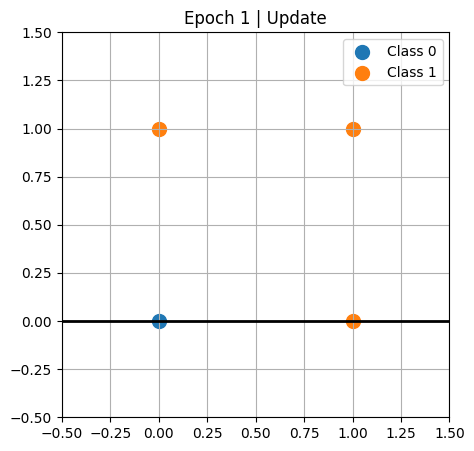

Updated Weights: [0.   0.01]
Updated Bias   : 0.0
Epoch  1/20
Misclassified Samples : 2
Weights : [0.   0.01]
Bias    : 0.0
--------------------------------------------------


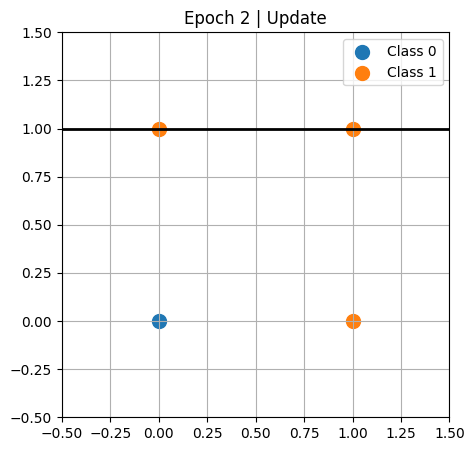

Updated Weights: [0.   0.01]
Updated Bias   : -0.01


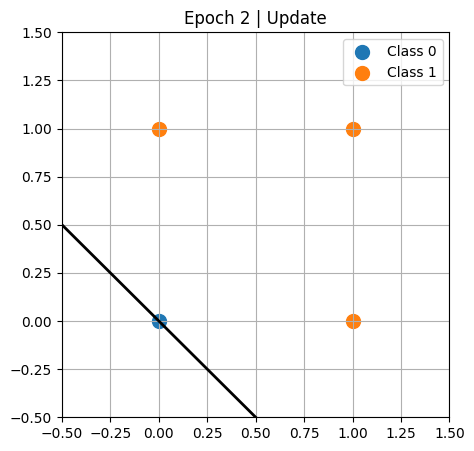

Updated Weights: [0.01 0.01]
Updated Bias   : 0.0
Epoch  2/20
Misclassified Samples : 2
Weights : [0.01 0.01]
Bias    : 0.0
--------------------------------------------------


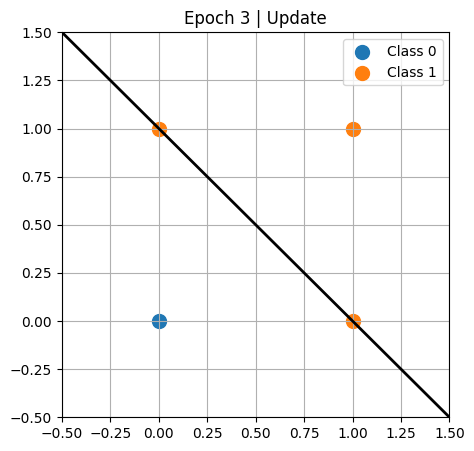

Updated Weights: [0.01 0.01]
Updated Bias   : -0.01
Epoch  3/20
Misclassified Samples : 1
Weights : [0.01 0.01]
Bias    : -0.01
--------------------------------------------------
Epoch  4/20
Misclassified Samples : 0
Weights : [0.01 0.01]
Bias    : -0.01
--------------------------------------------------
Training converged successfully!


In [63]:
#Perceptron for OR gate
y = np.array([0,1,1,1])

perceptron = Perceptron(learning_rate=0.01, epochs=20)
perceptron.fit(X, y)

In [72]:
#perceptron for not gate
X = np.array([
    [0],
    [1]
])

y = np.array([1,0])

perceptron = Perceptron(learning_rate=0.01, epochs=20)
perceptron.fit(X, y)

Epoch  1/20
Misclassified Samples : 1
Weights : [-0.01]
Bias    : -0.01
--------------------------------------------------
Epoch  2/20
Misclassified Samples : 1
Weights : [-0.01]
Bias    : 0.0
--------------------------------------------------
Epoch  3/20
Misclassified Samples : 0
Weights : [-0.01]
Bias    : 0.0
--------------------------------------------------
Training converged successfully!


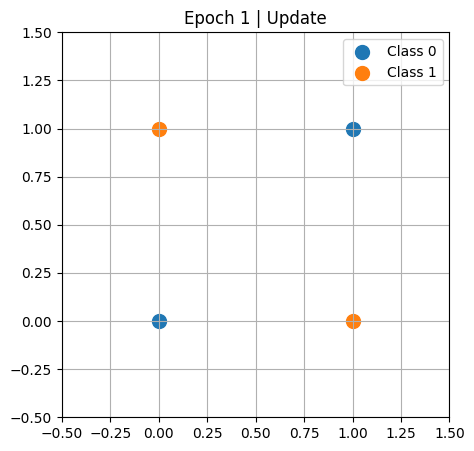

Updated Weights: [0. 0.]
Updated Bias   : -0.01


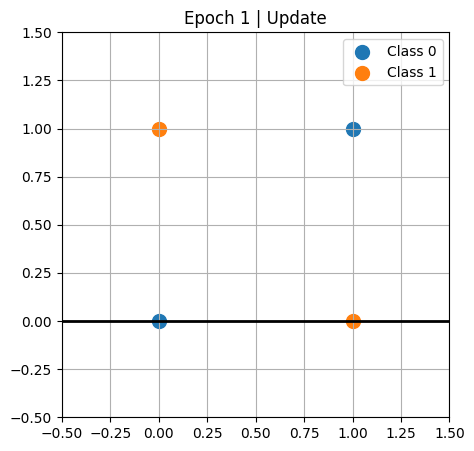

Updated Weights: [0.   0.01]
Updated Bias   : 0.0


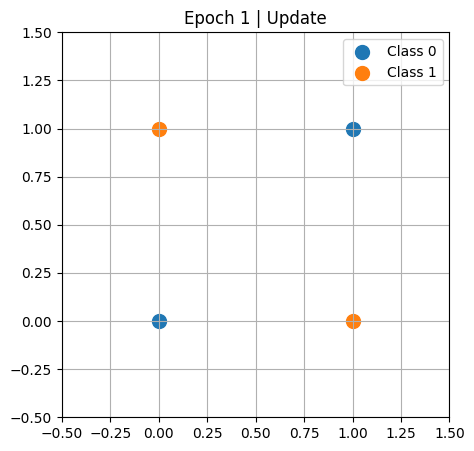

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01
Epoch  1/50
Misclassified Samples : 3
Weights : [-0.01  0.  ]
Bias    : -0.01
--------------------------------------------------


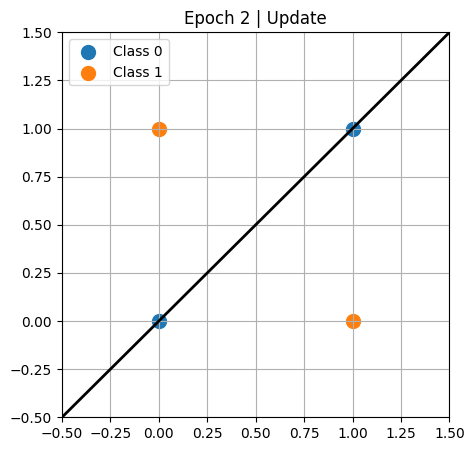

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


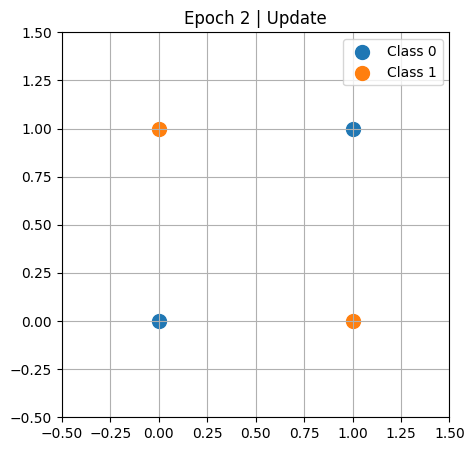

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


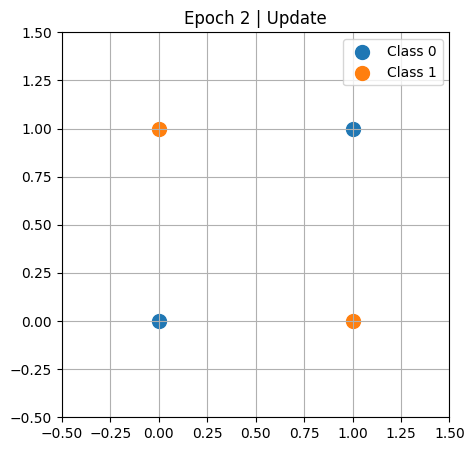

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  2/50
Misclassified Samples : 3
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


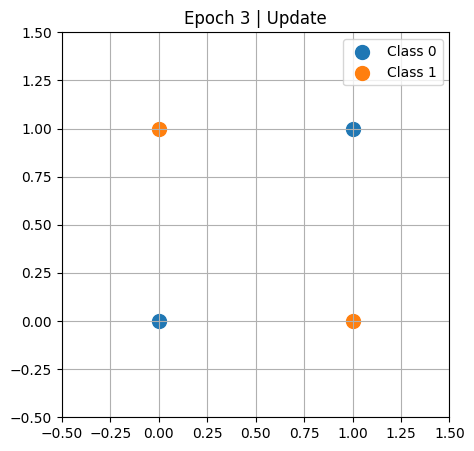

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


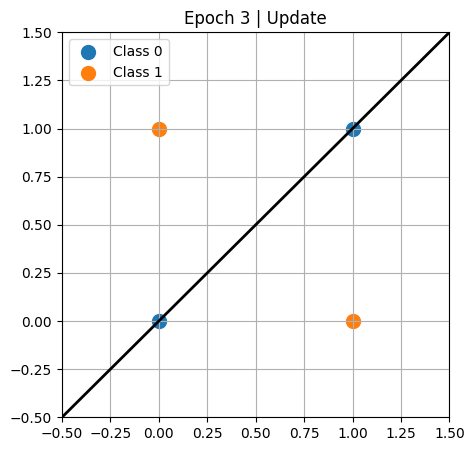

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


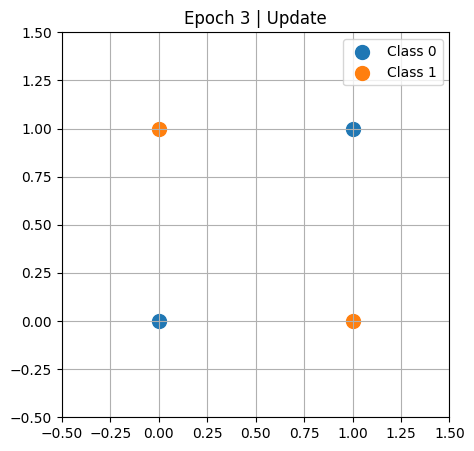

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


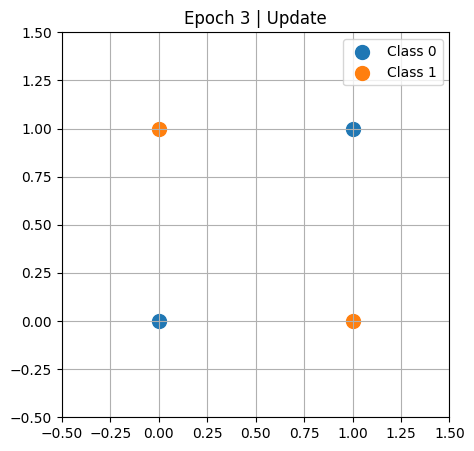

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  3/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


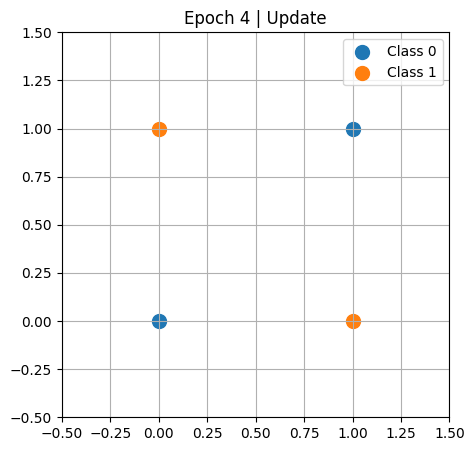

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


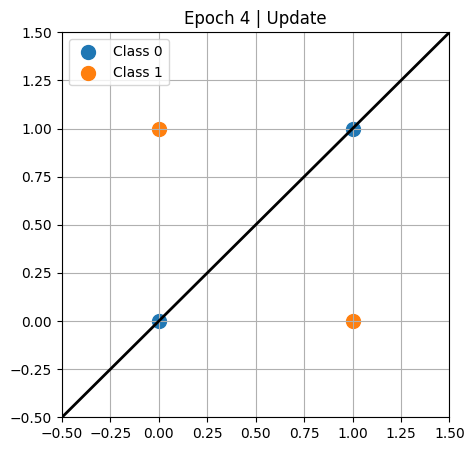

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


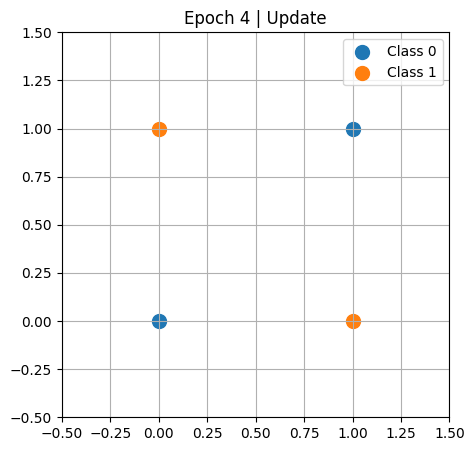

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


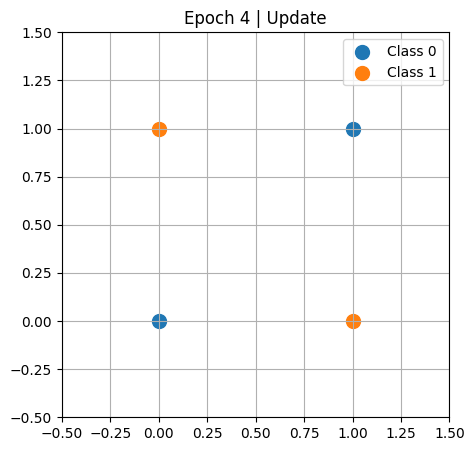

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  4/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


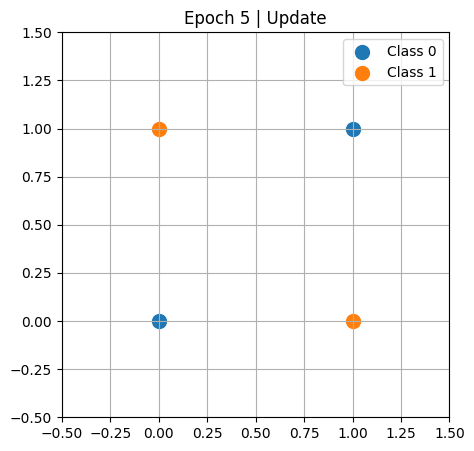

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


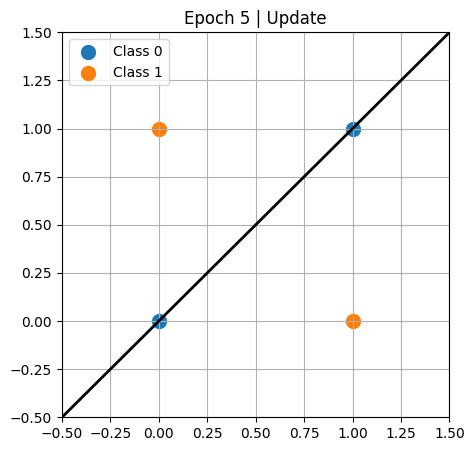

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


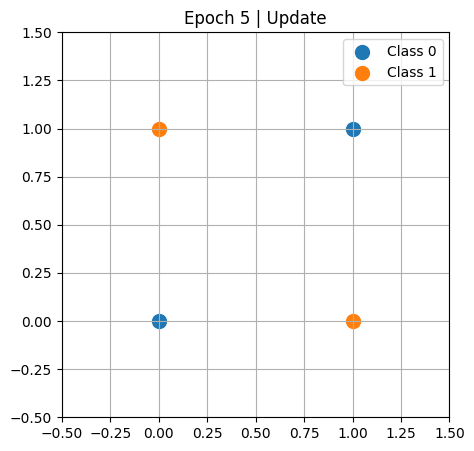

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


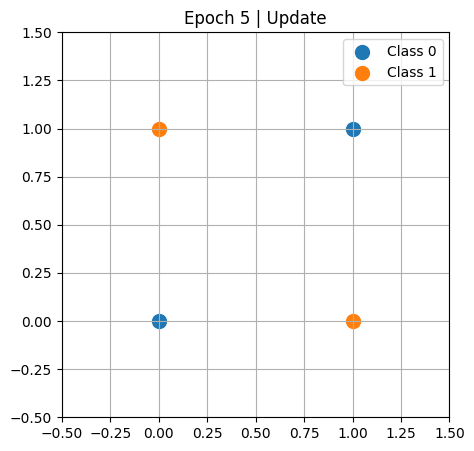

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  5/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


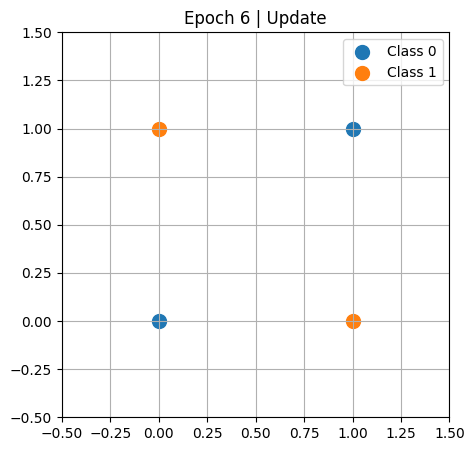

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


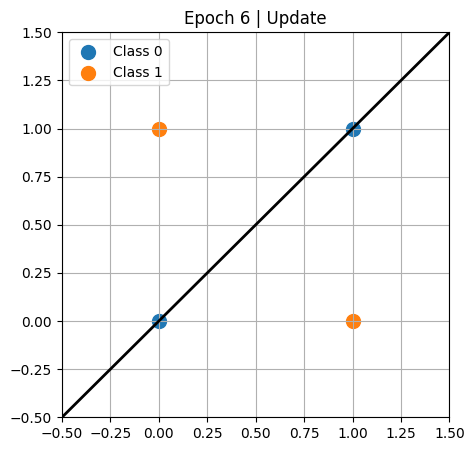

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


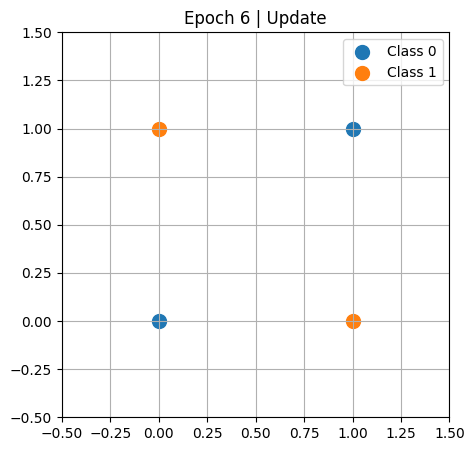

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


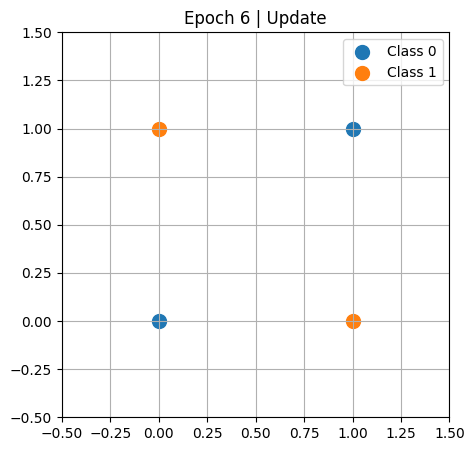

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  6/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


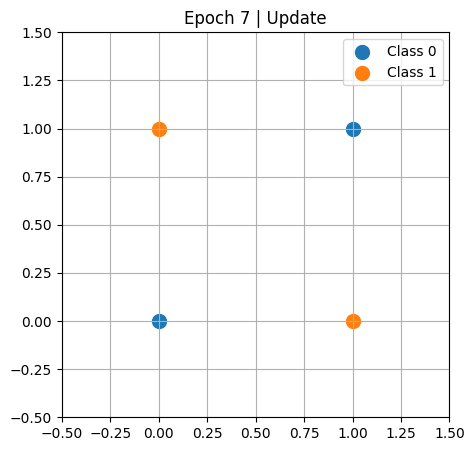

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


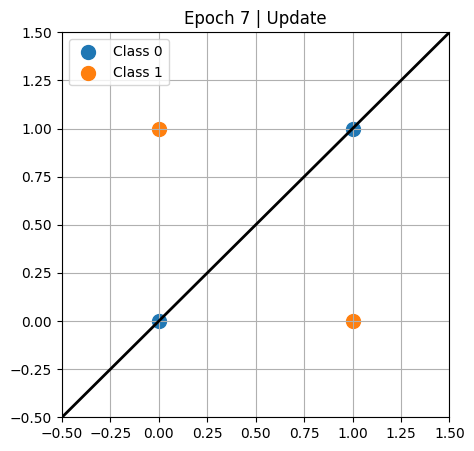

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


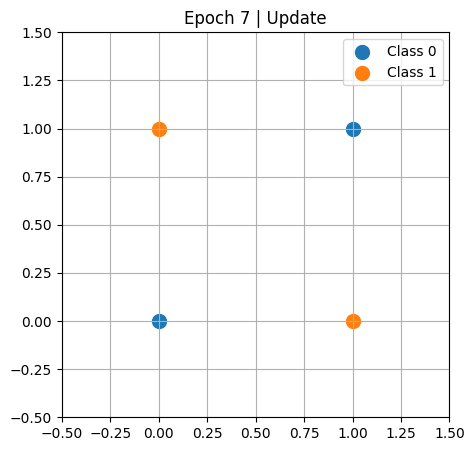

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


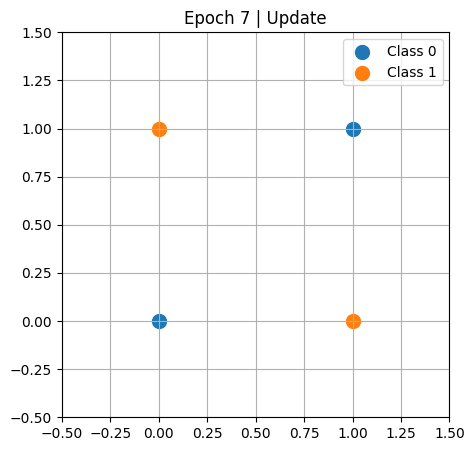

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  7/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


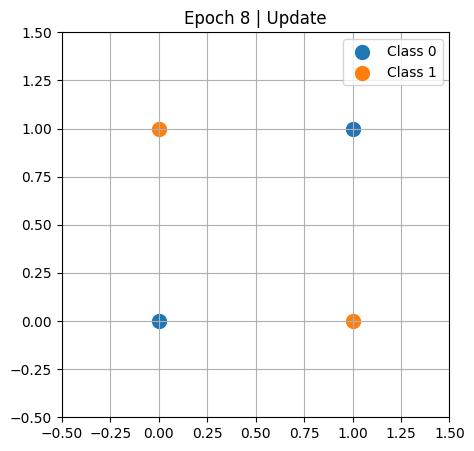

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


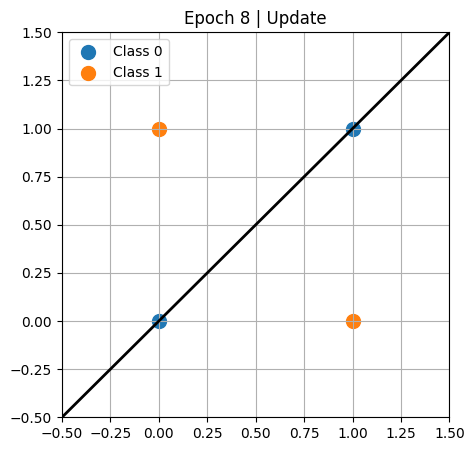

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


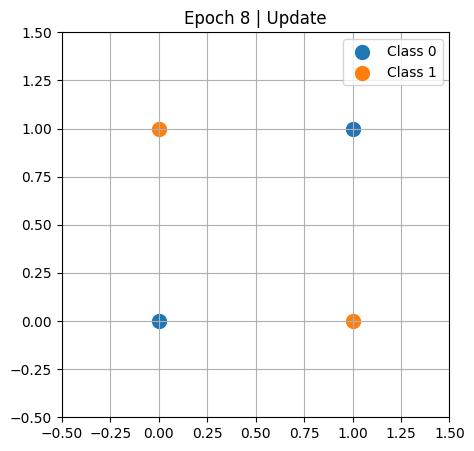

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


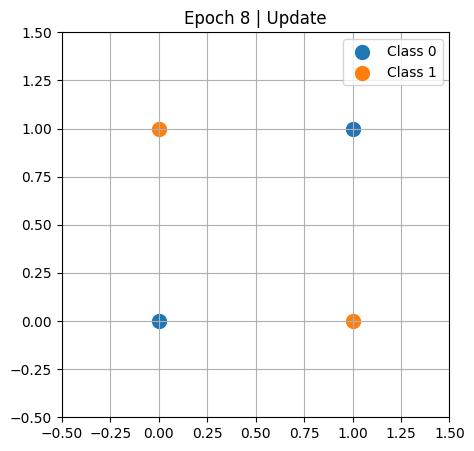

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  8/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


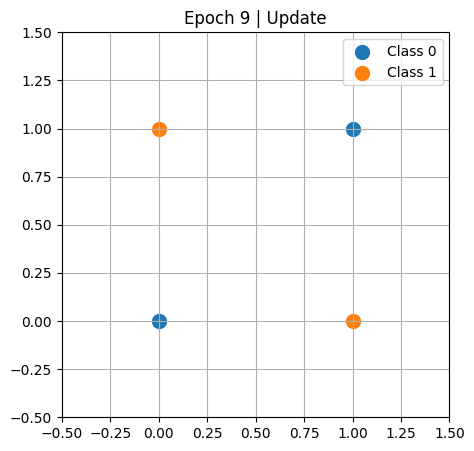

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


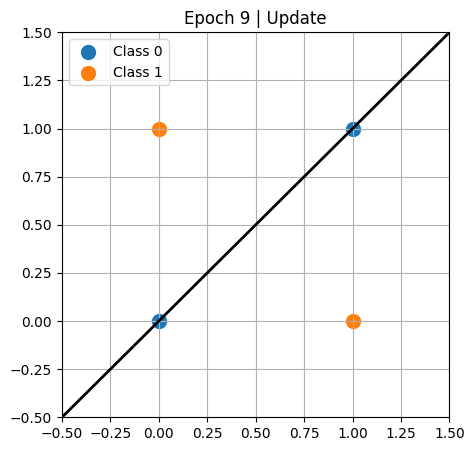

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


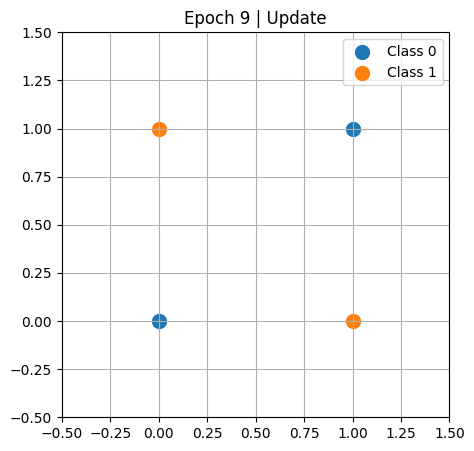

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


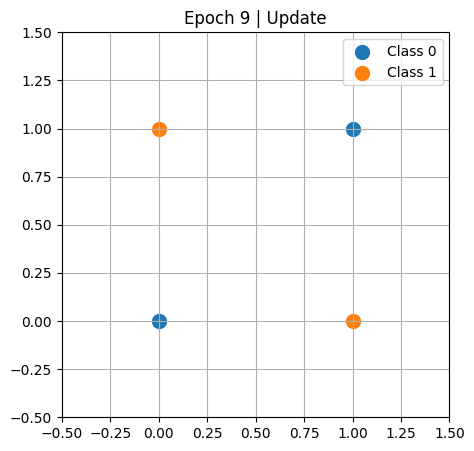

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch  9/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


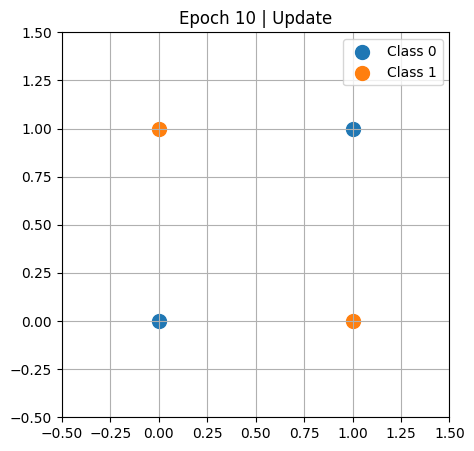

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


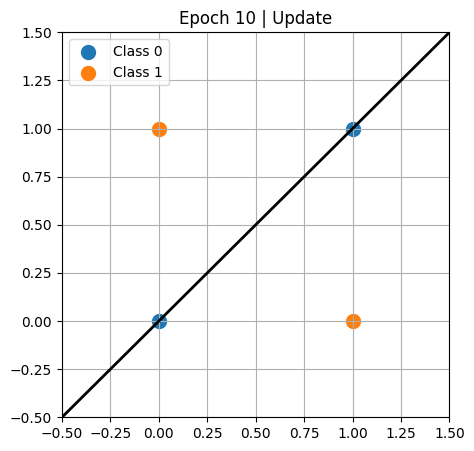

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


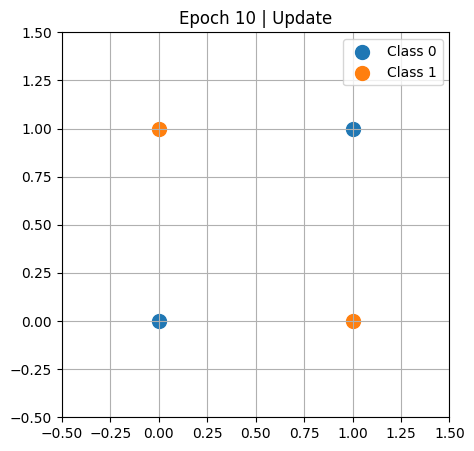

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


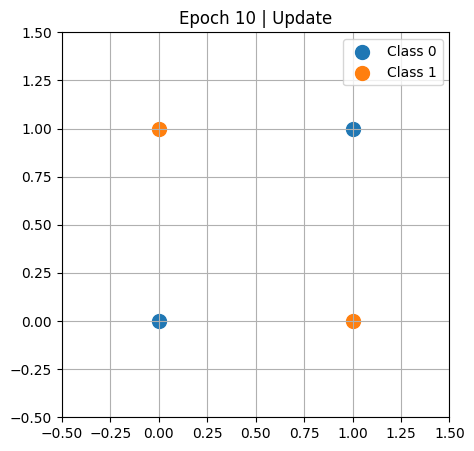

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 10/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


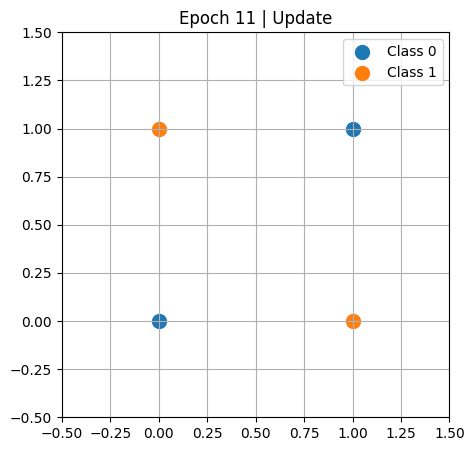

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


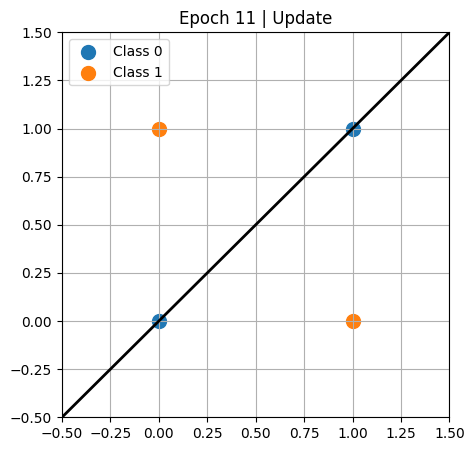

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


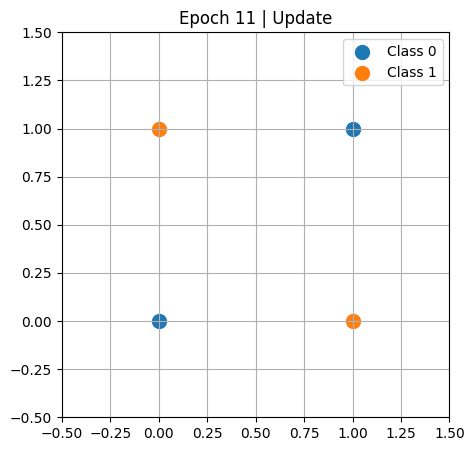

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


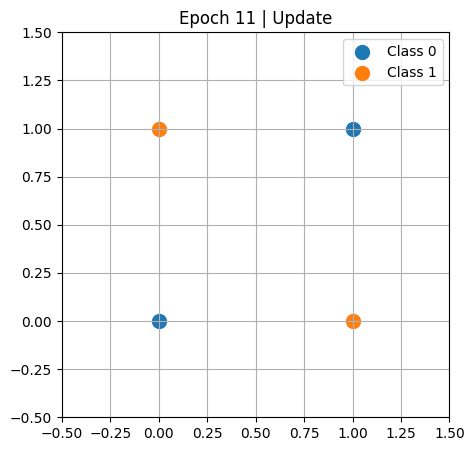

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 11/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


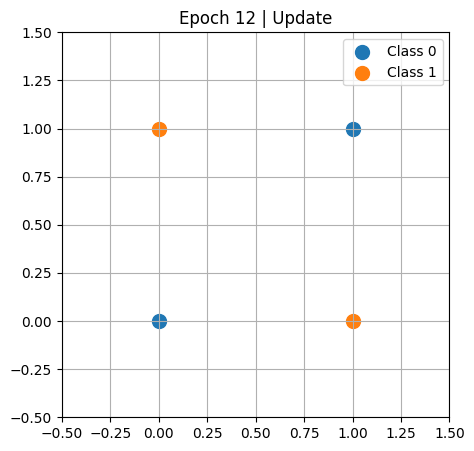

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


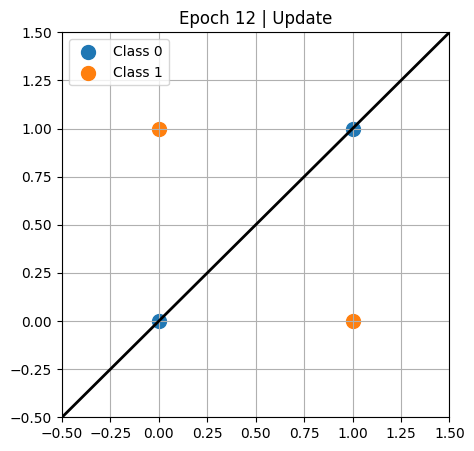

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


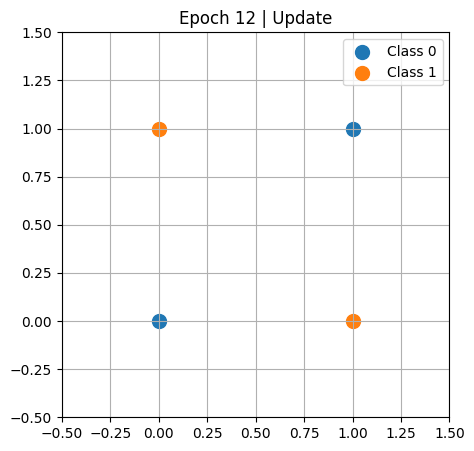

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


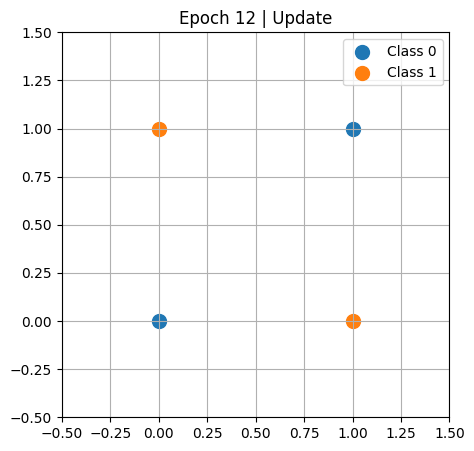

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 12/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


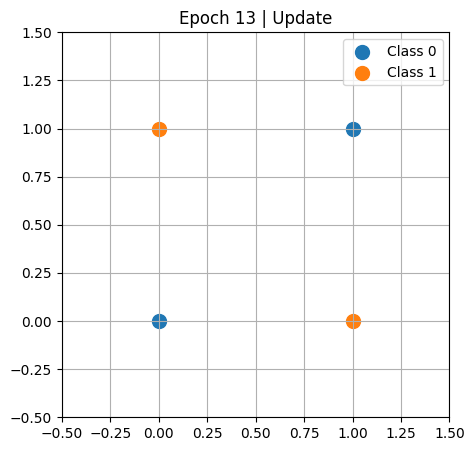

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


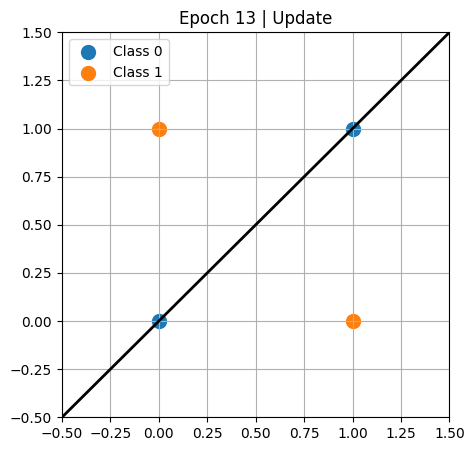

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


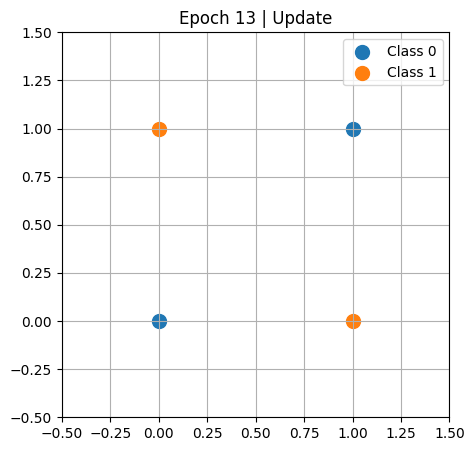

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


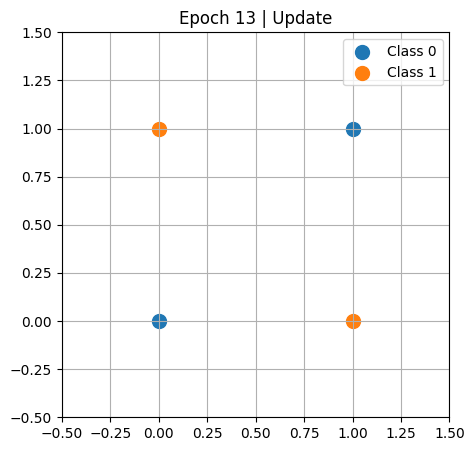

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 13/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


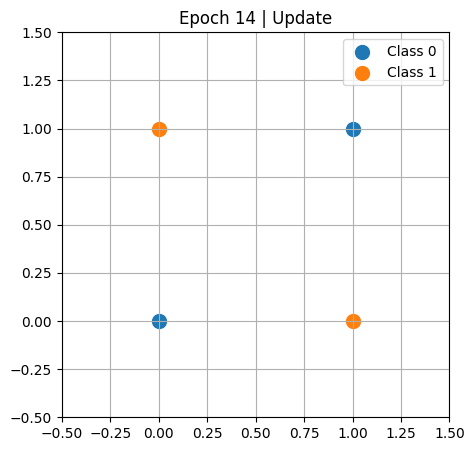

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


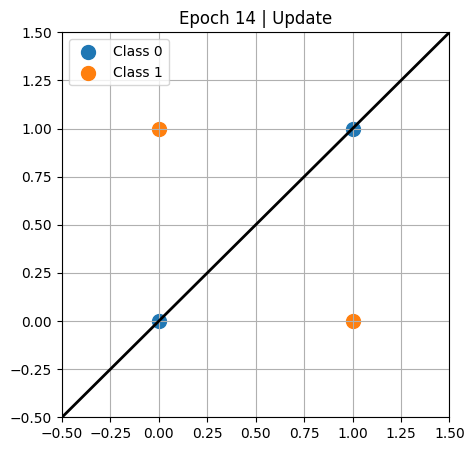

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


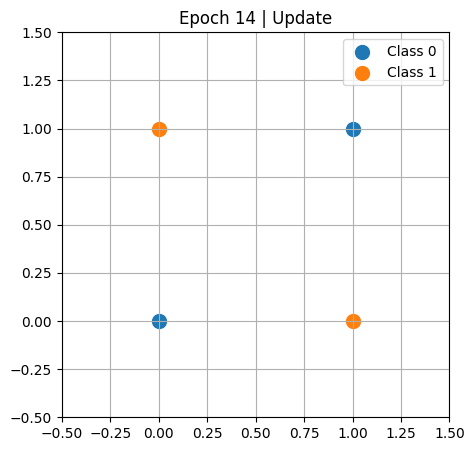

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


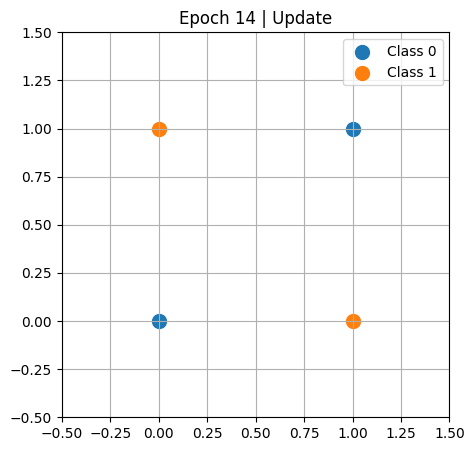

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 14/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


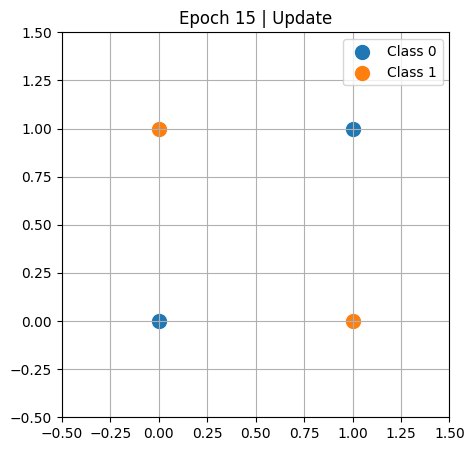

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


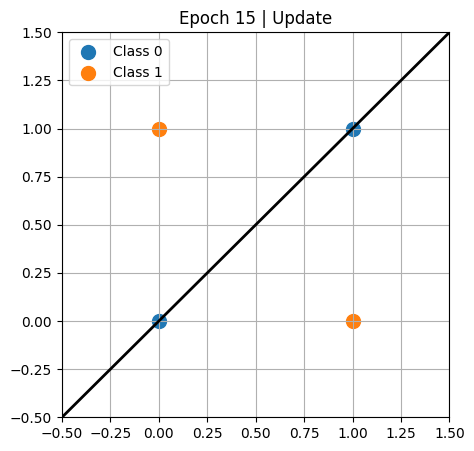

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


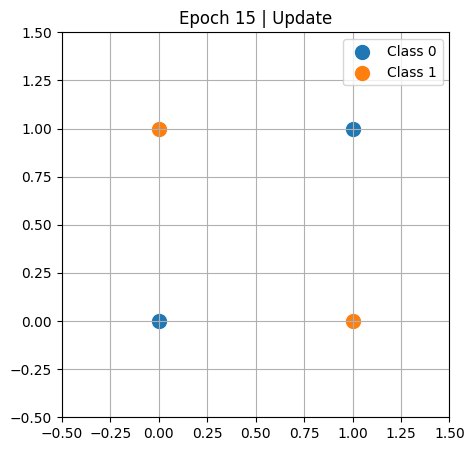

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


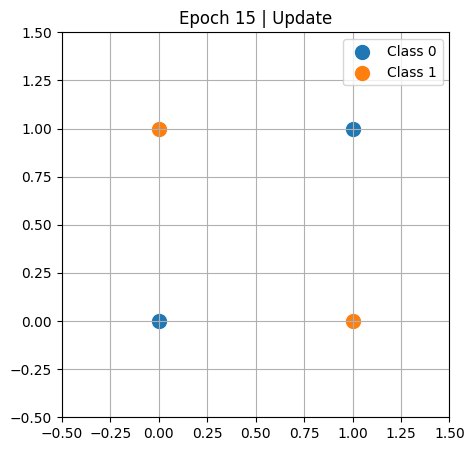

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 15/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


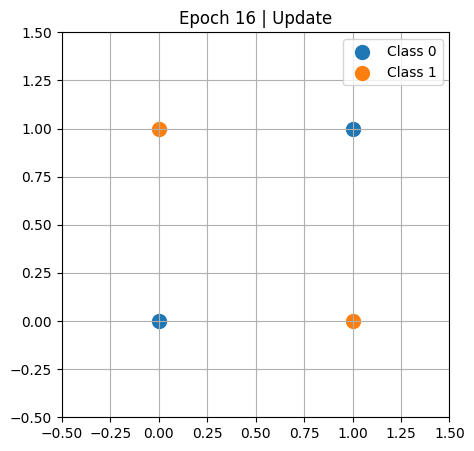

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


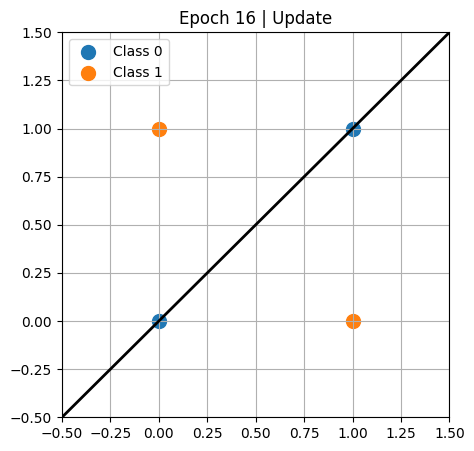

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


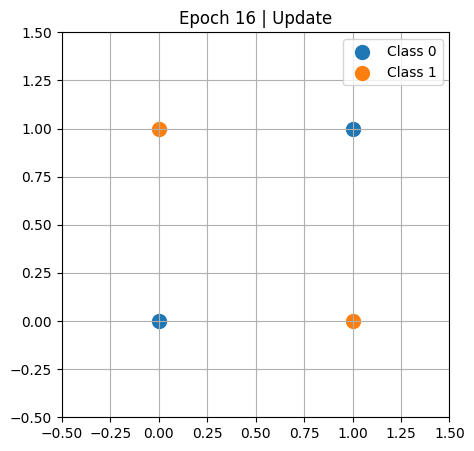

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


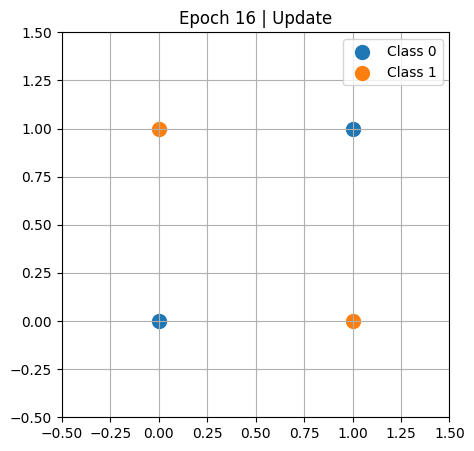

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 16/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


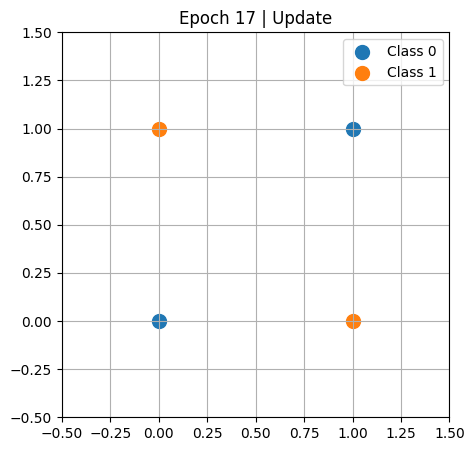

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


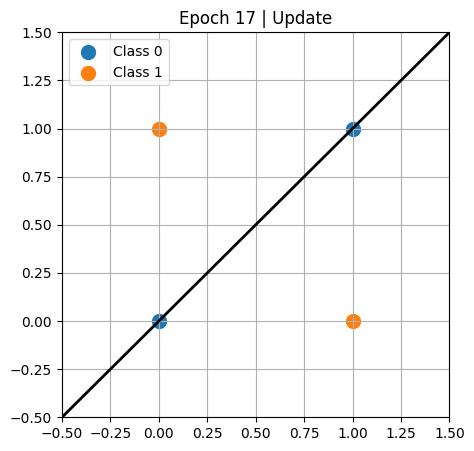

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


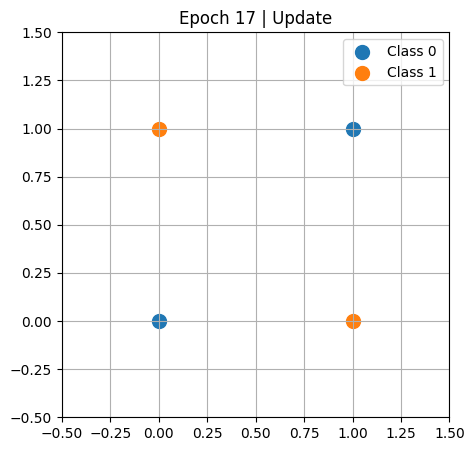

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


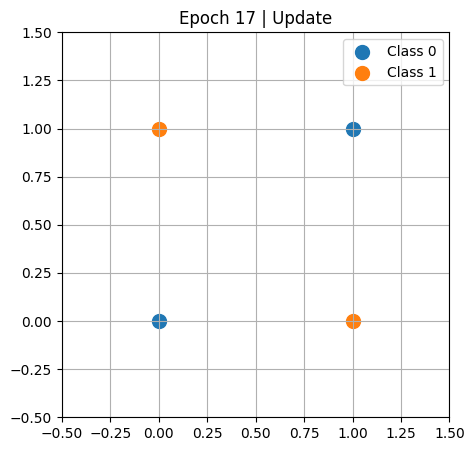

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 17/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


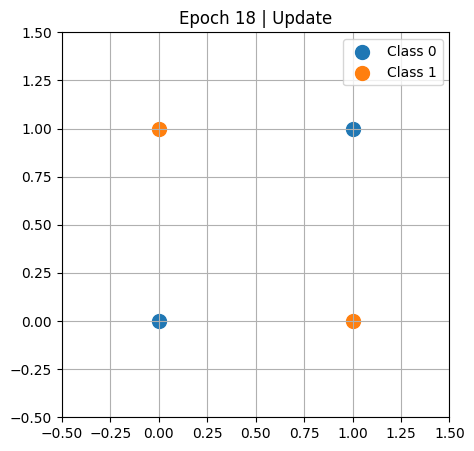

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


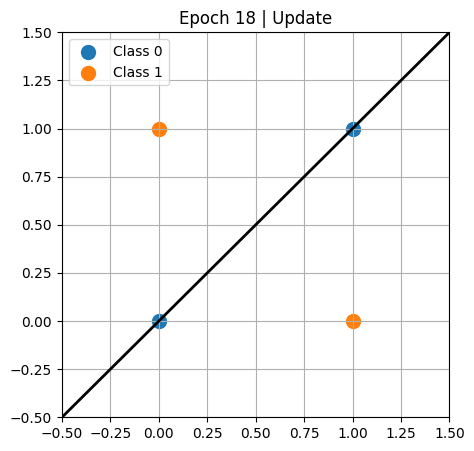

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


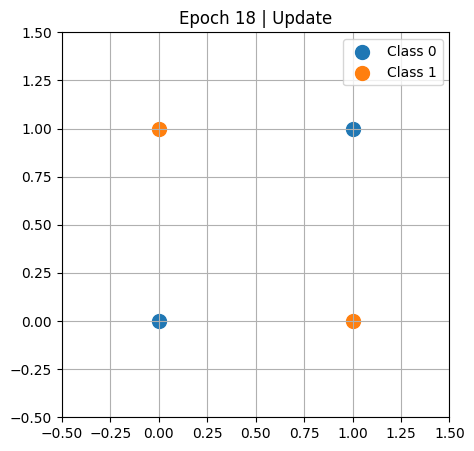

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


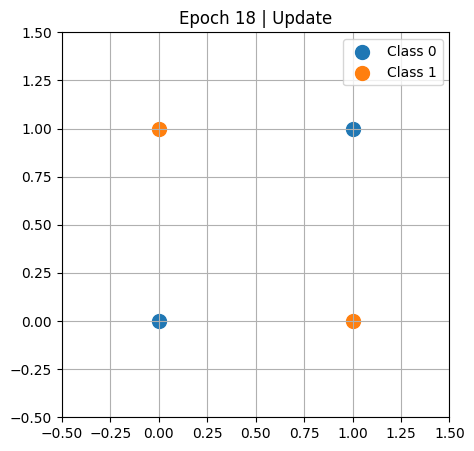

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 18/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


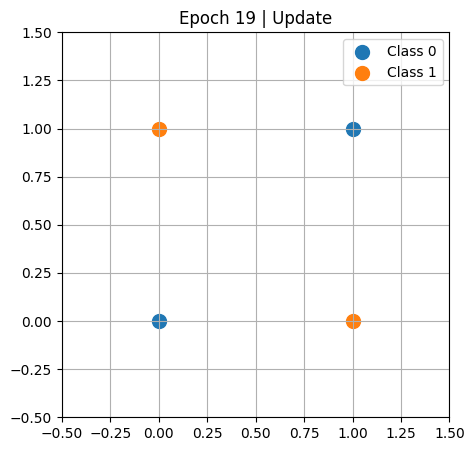

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


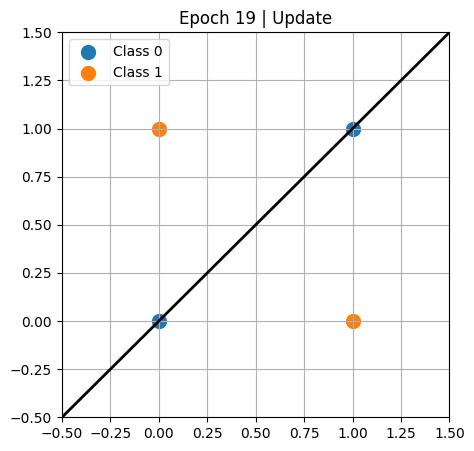

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


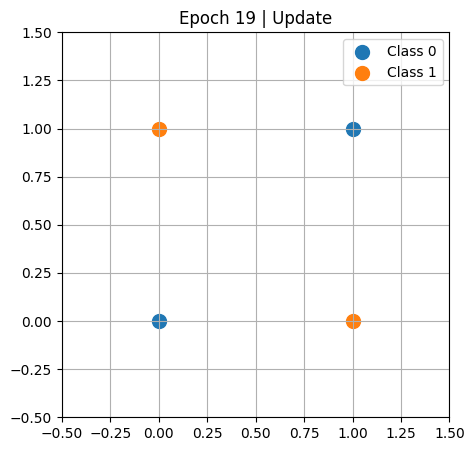

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


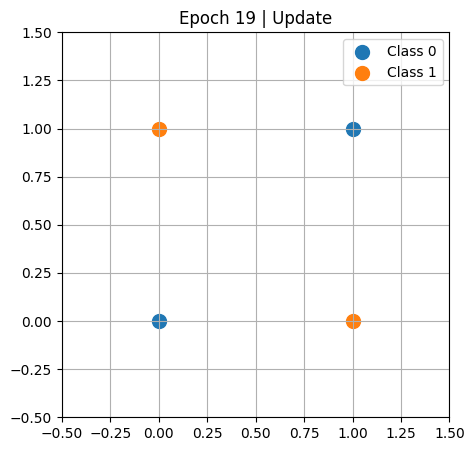

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 19/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


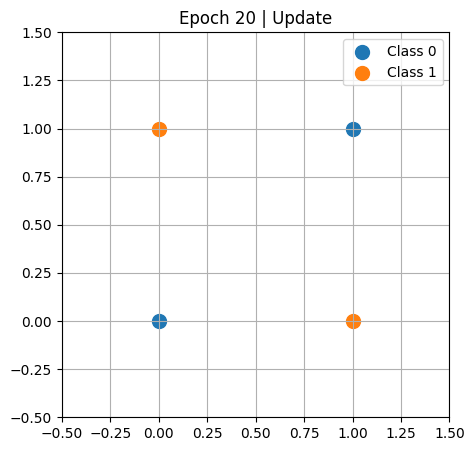

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


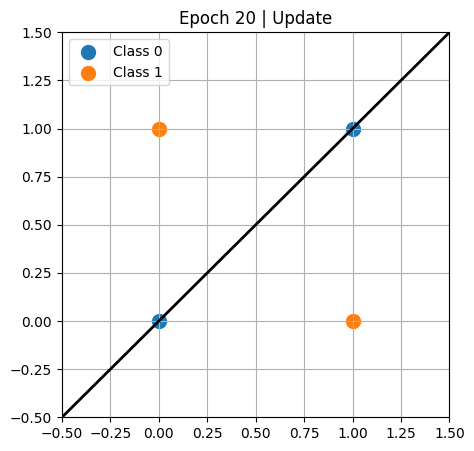

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


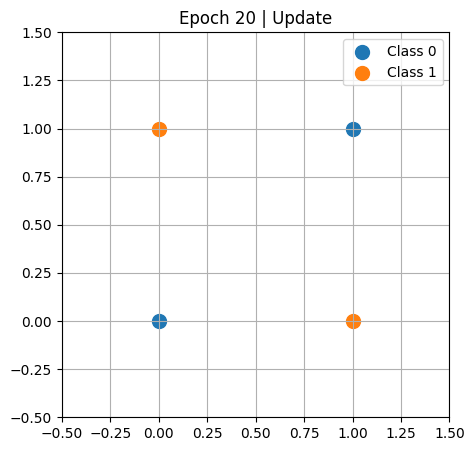

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


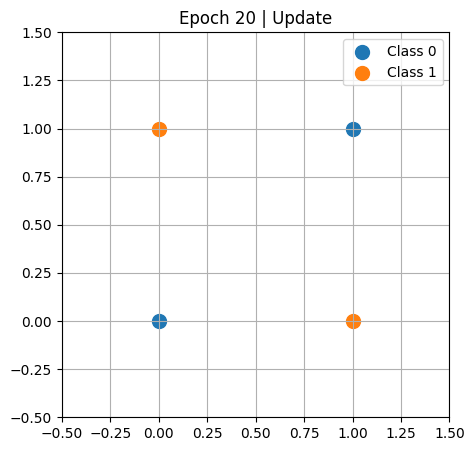

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 20/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


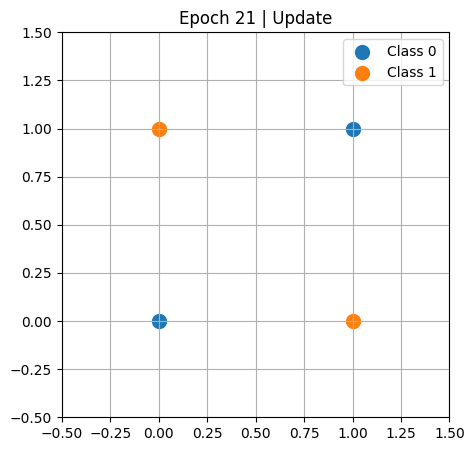

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


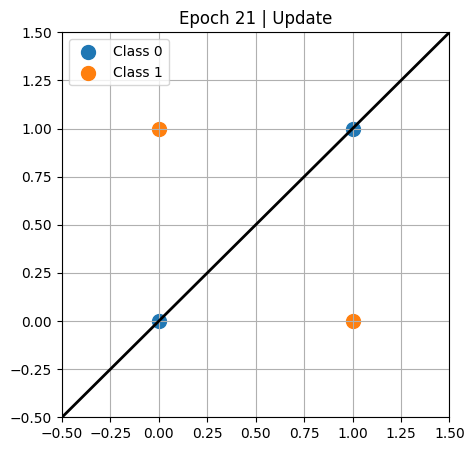

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


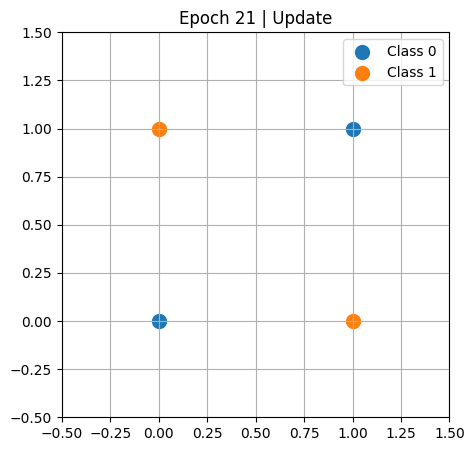

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


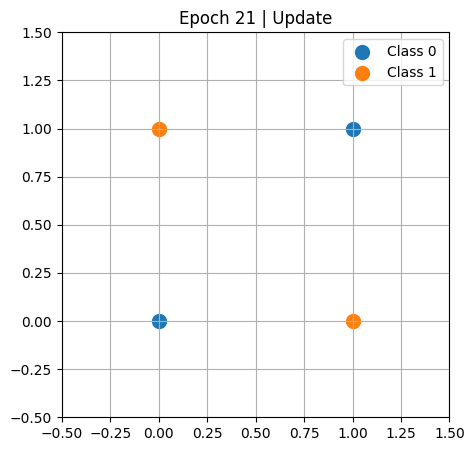

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 21/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


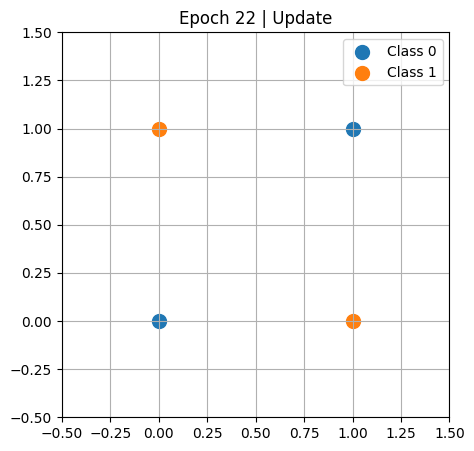

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


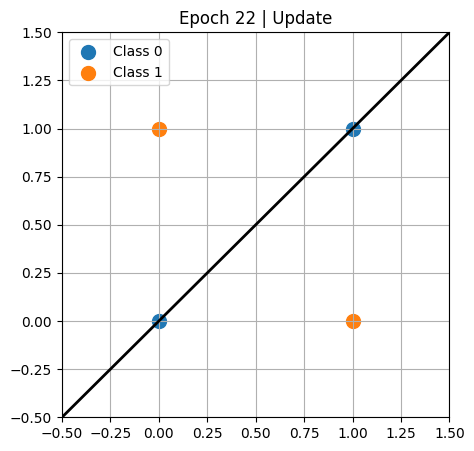

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


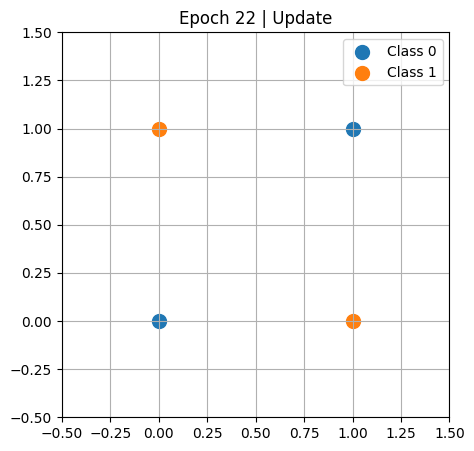

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


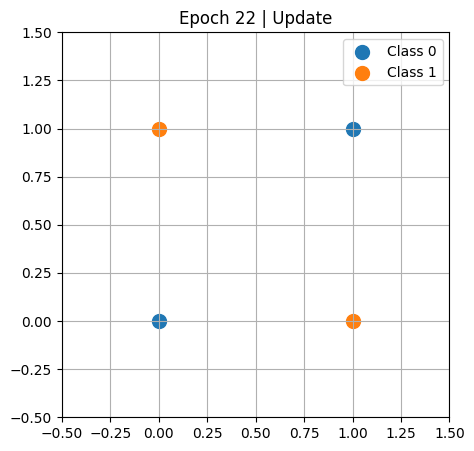

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 22/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


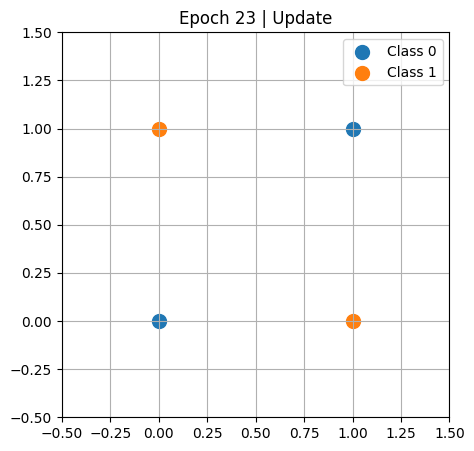

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


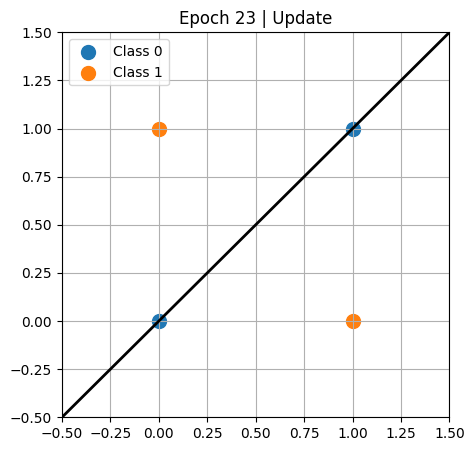

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


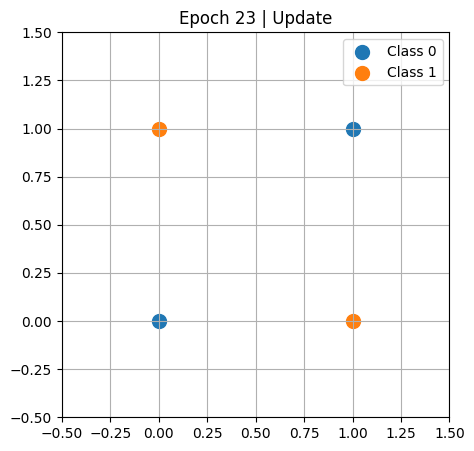

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


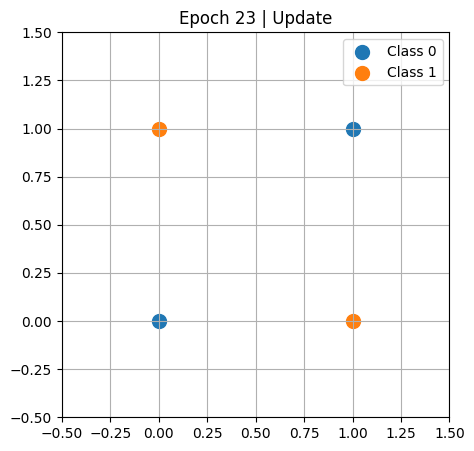

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 23/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


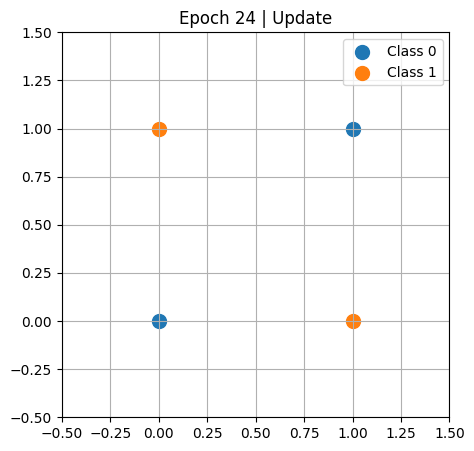

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


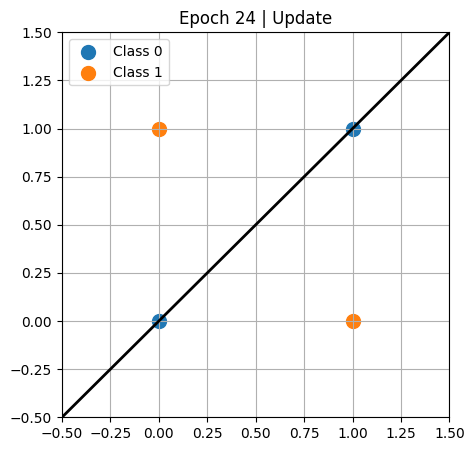

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


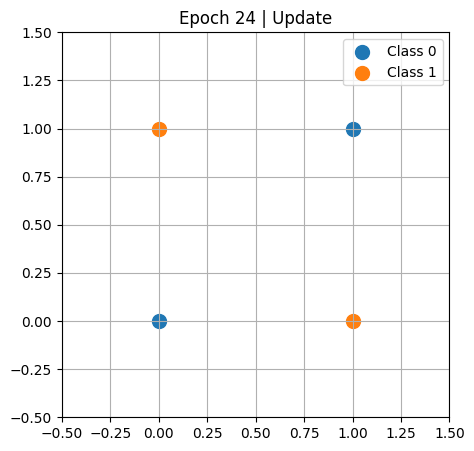

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


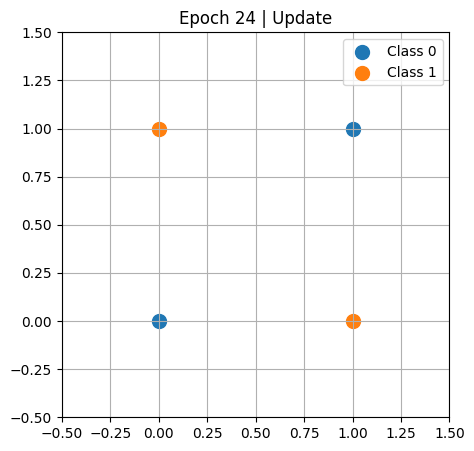

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 24/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


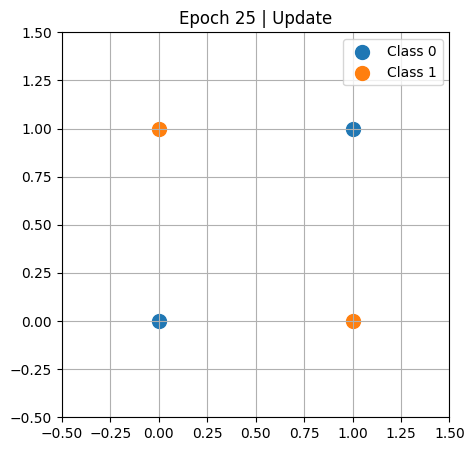

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


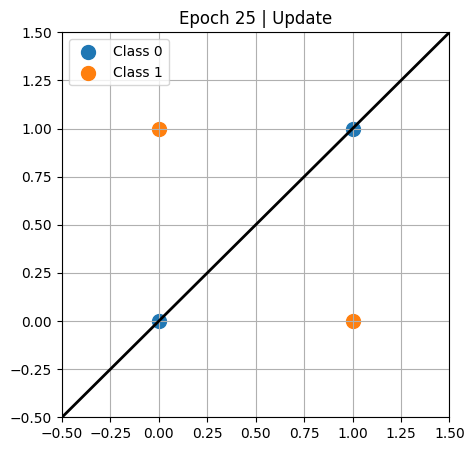

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


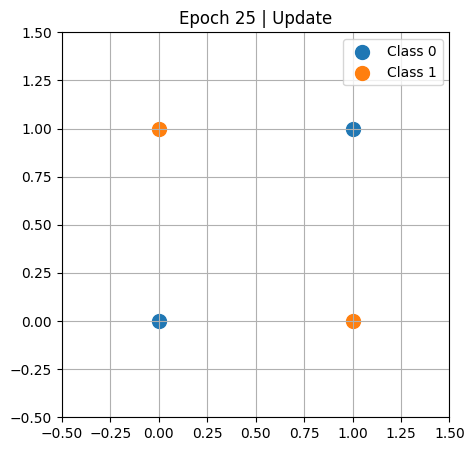

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


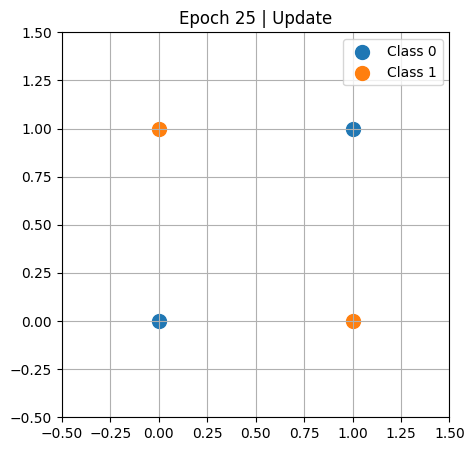

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 25/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


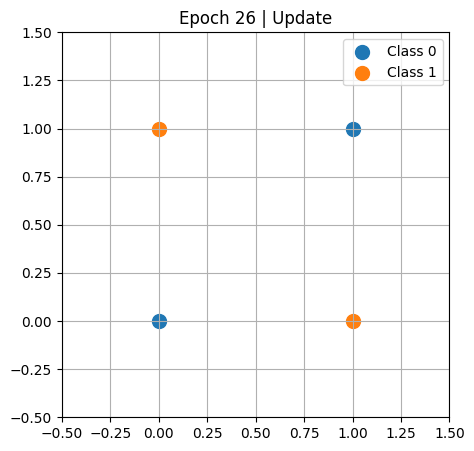

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


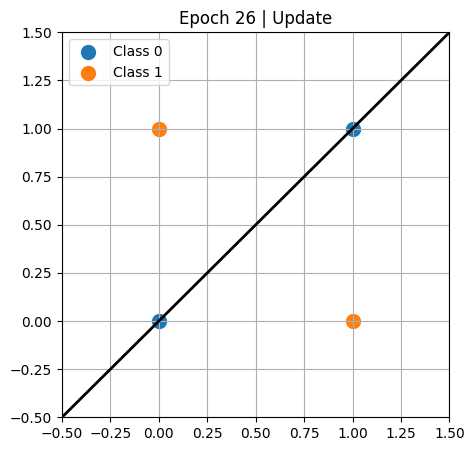

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


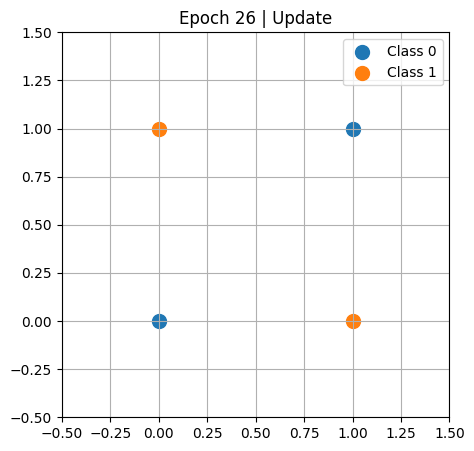

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


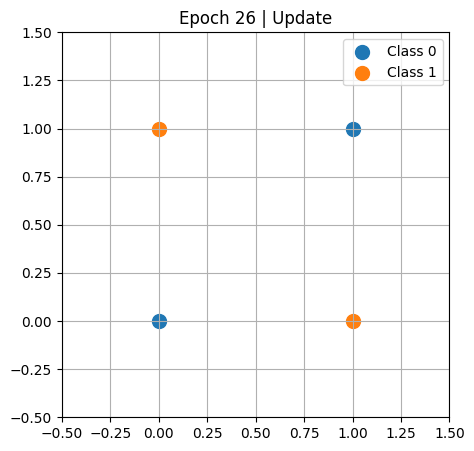

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 26/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


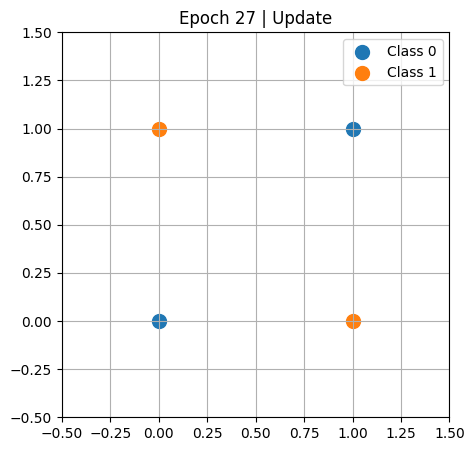

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


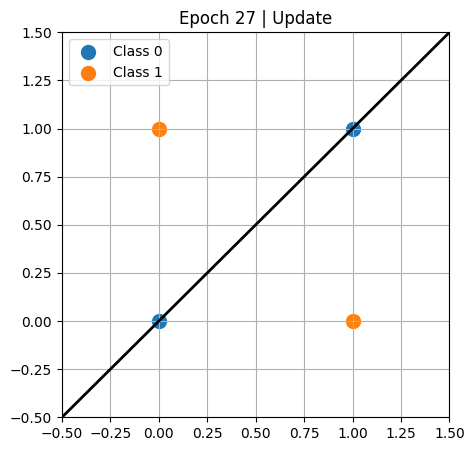

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


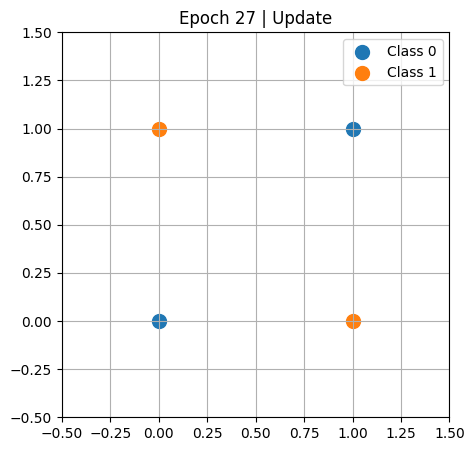

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


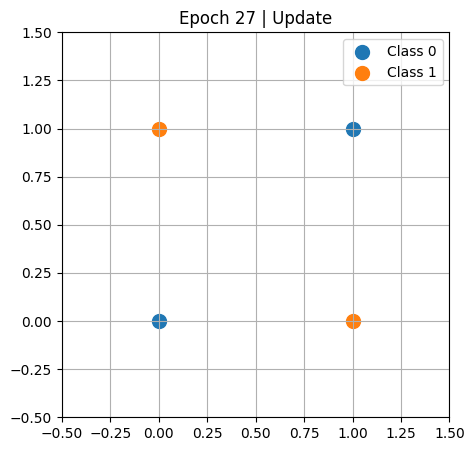

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 27/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


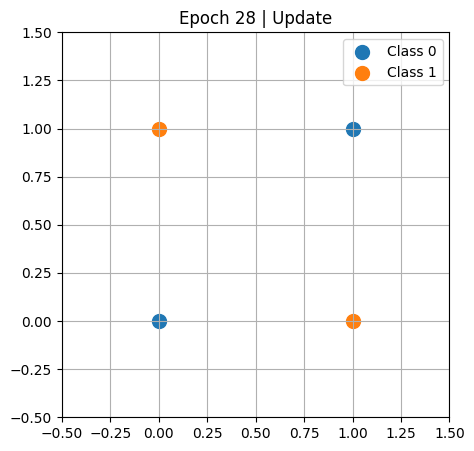

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


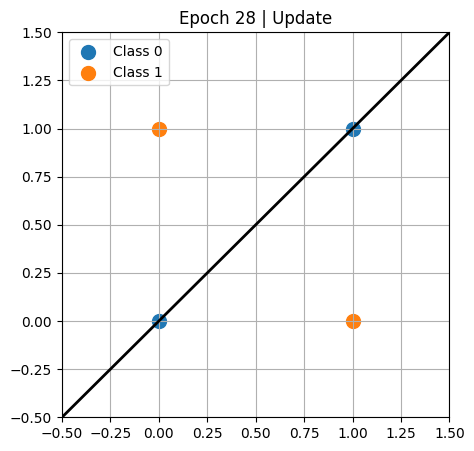

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


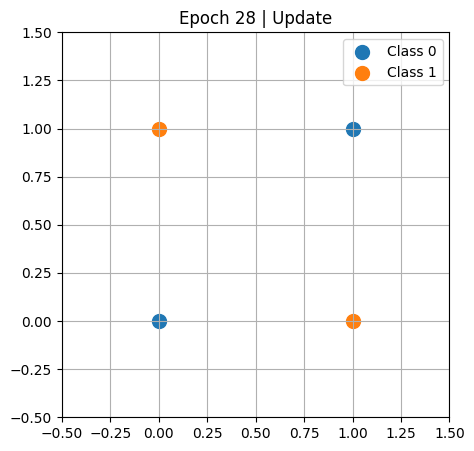

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


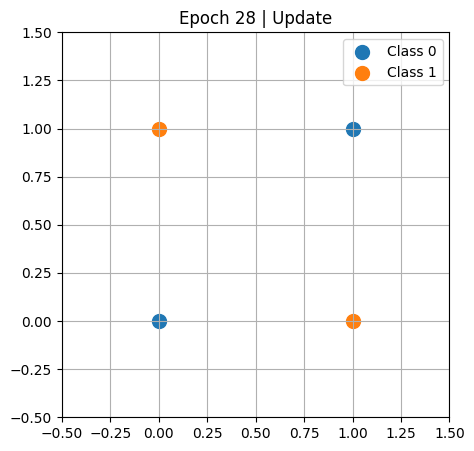

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 28/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


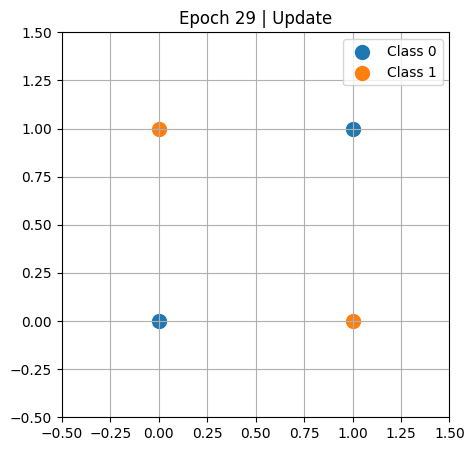

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


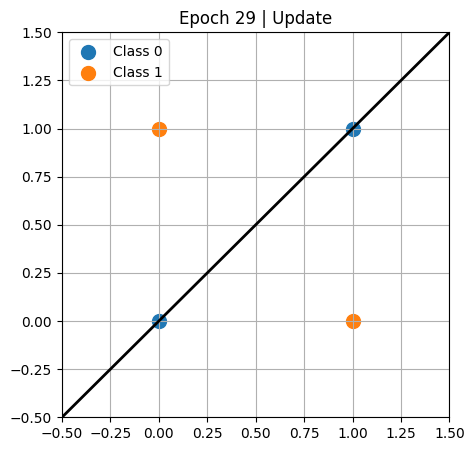

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


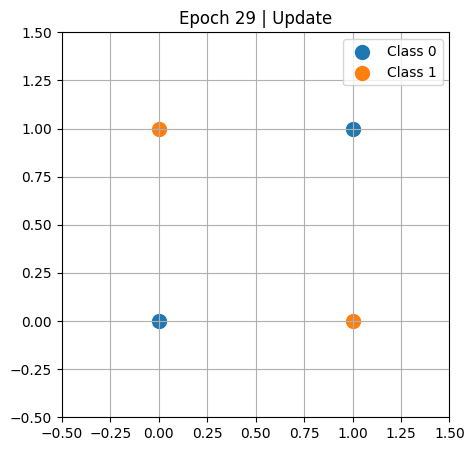

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


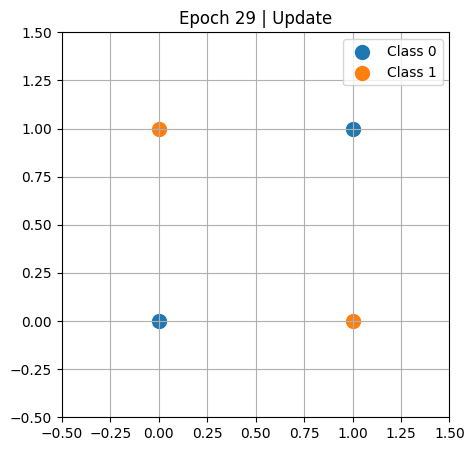

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 29/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


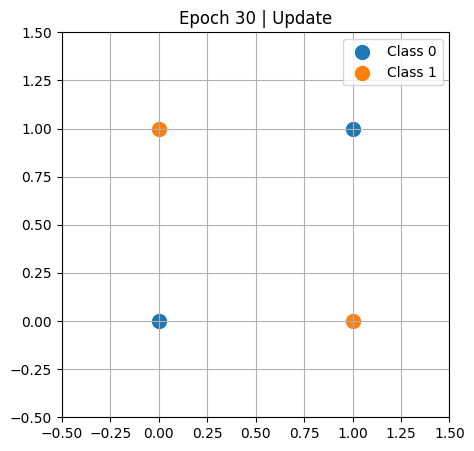

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


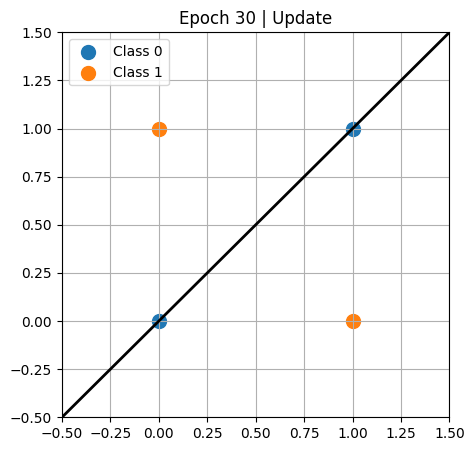

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


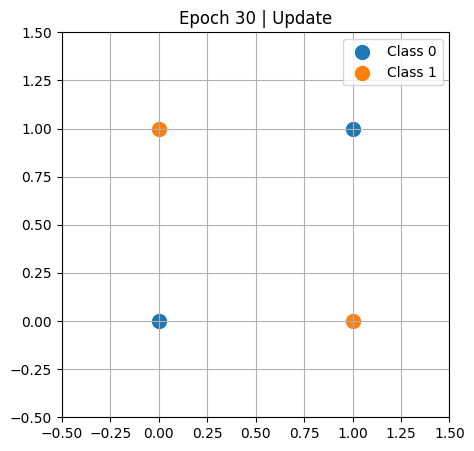

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


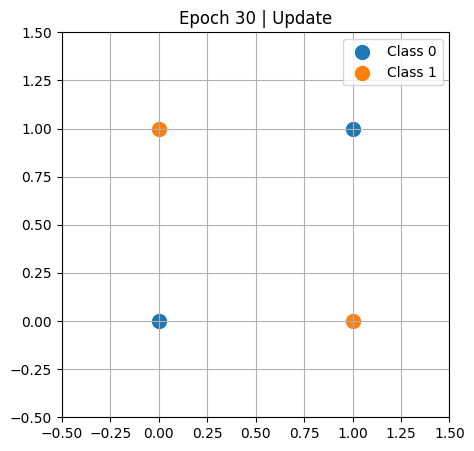

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 30/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


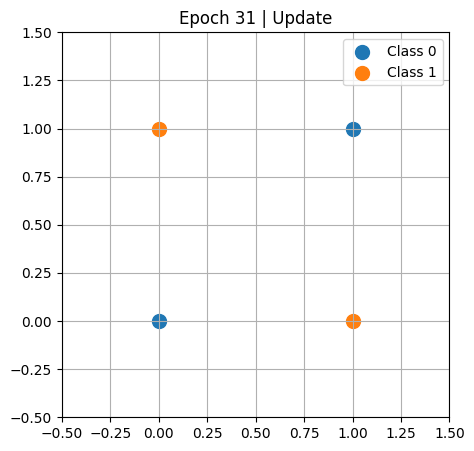

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


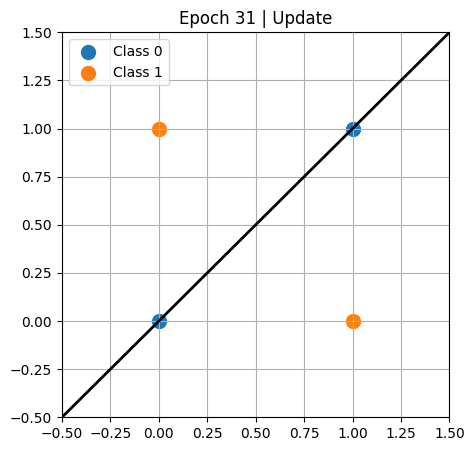

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


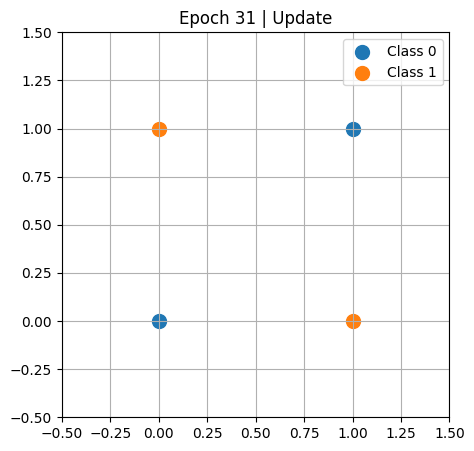

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


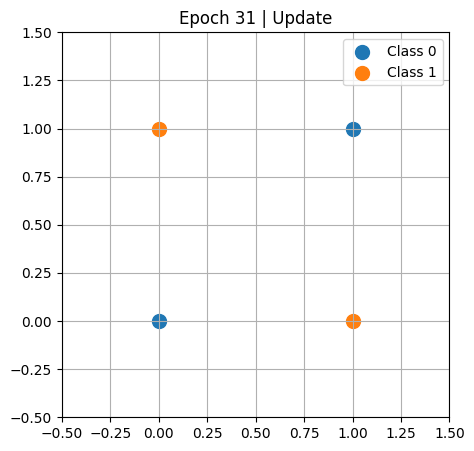

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 31/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


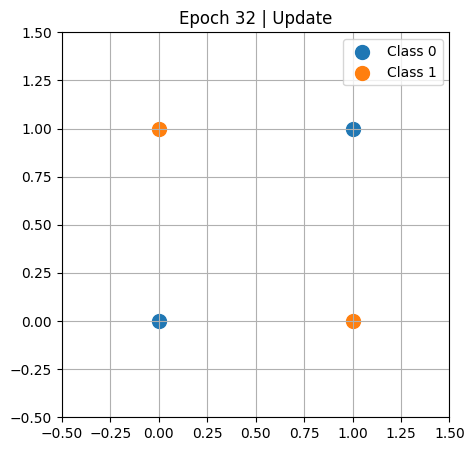

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


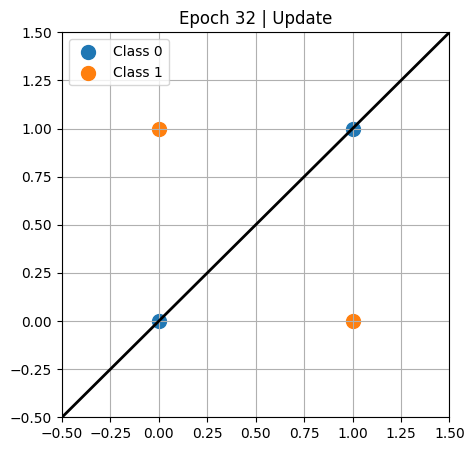

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


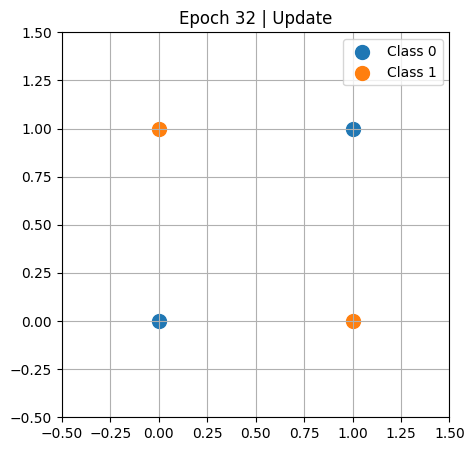

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


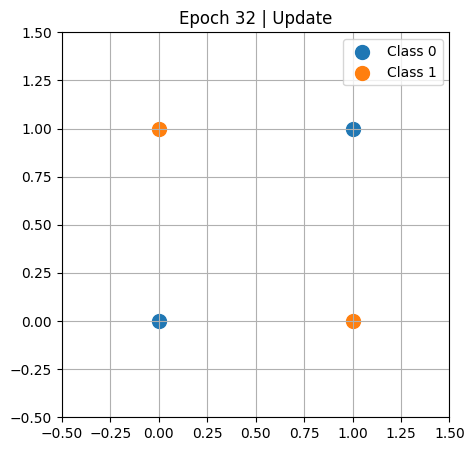

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 32/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


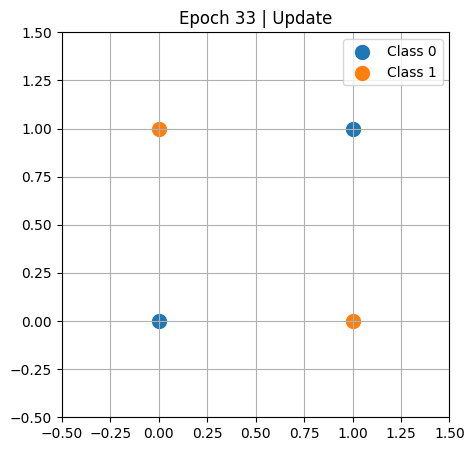

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


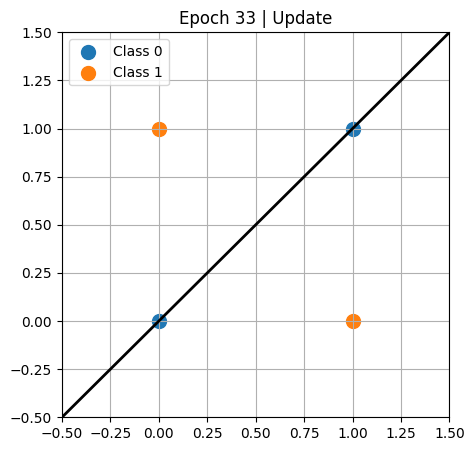

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


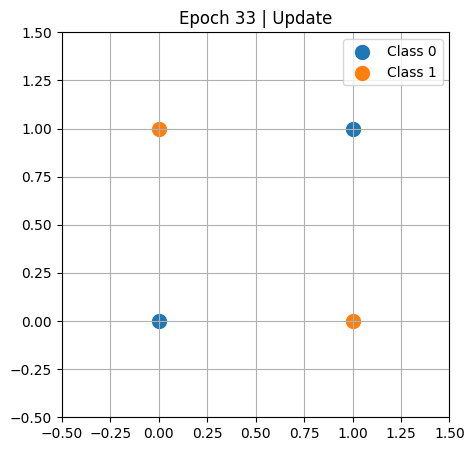

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


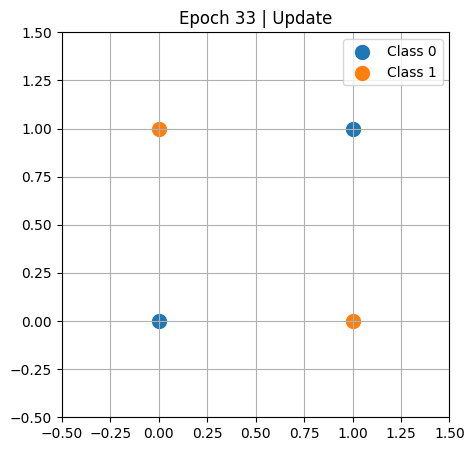

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 33/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


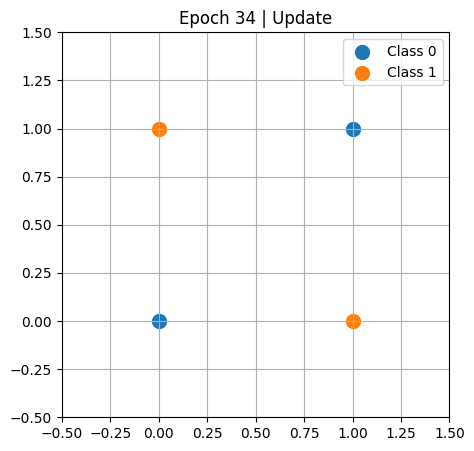

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


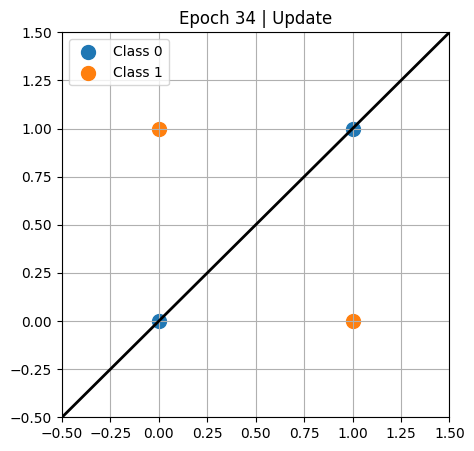

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


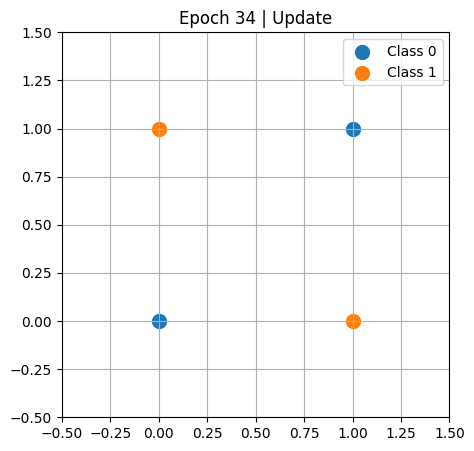

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


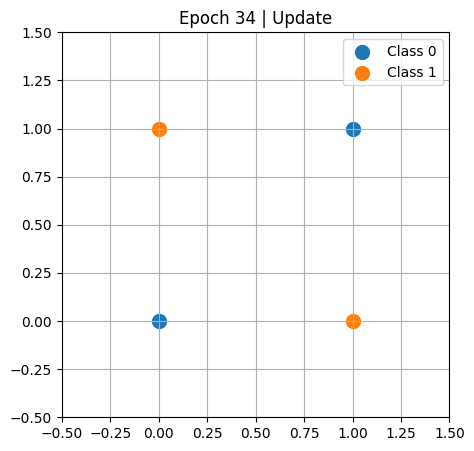

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 34/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


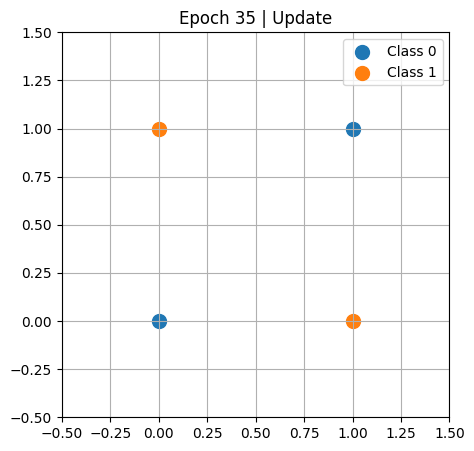

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


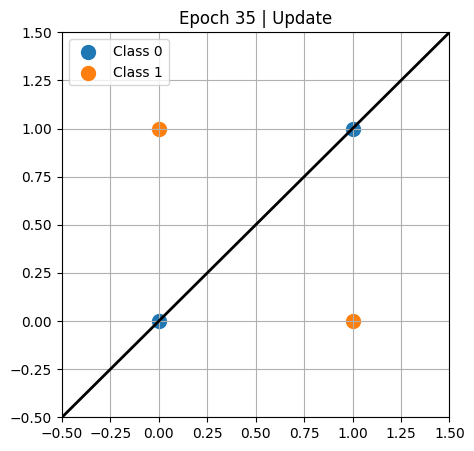

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


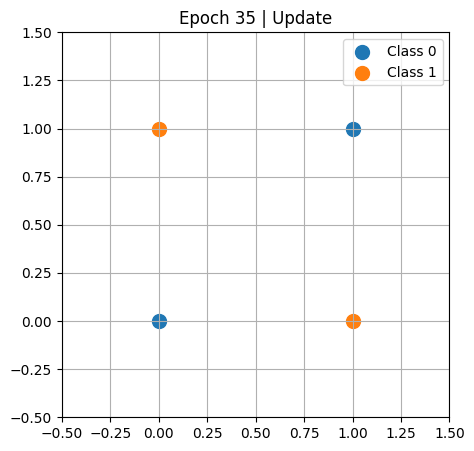

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


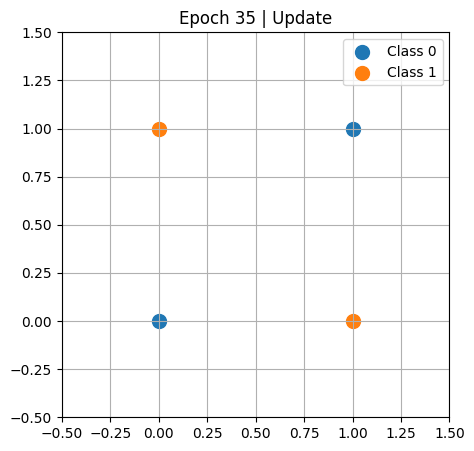

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 35/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


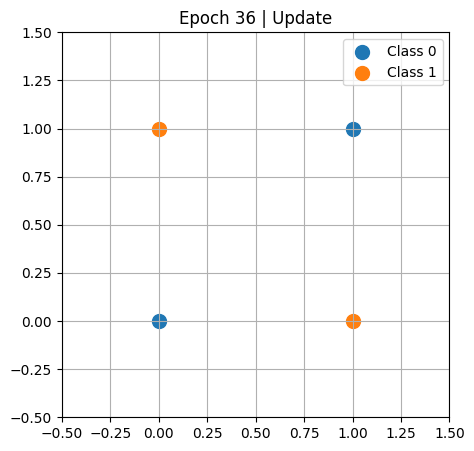

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


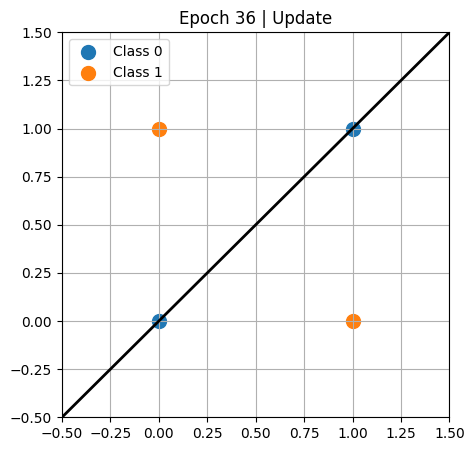

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


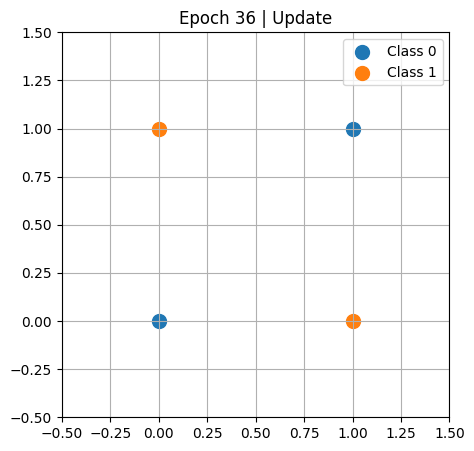

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


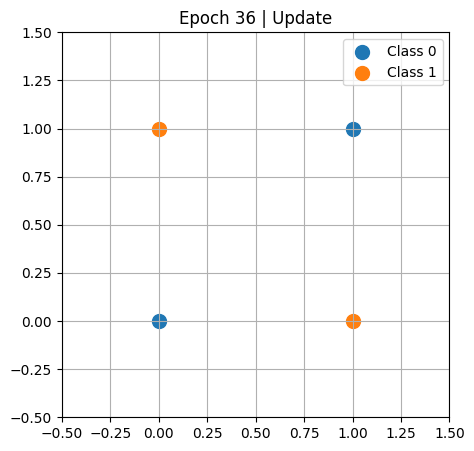

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 36/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


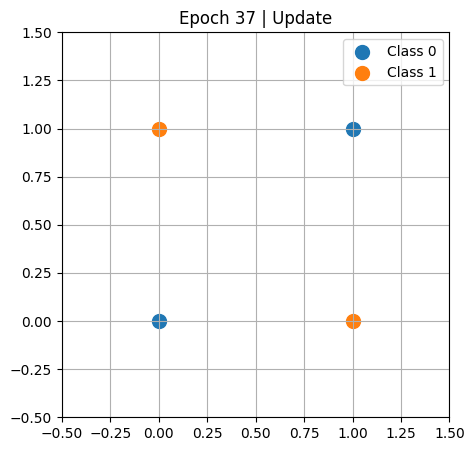

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


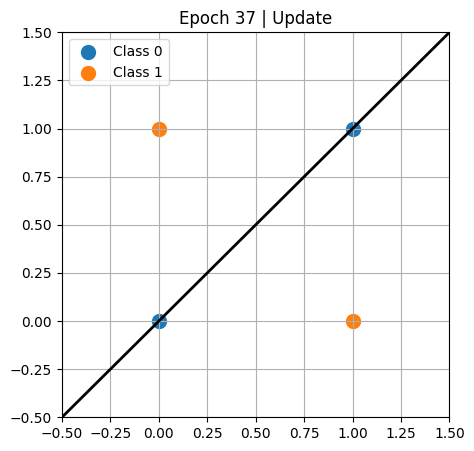

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


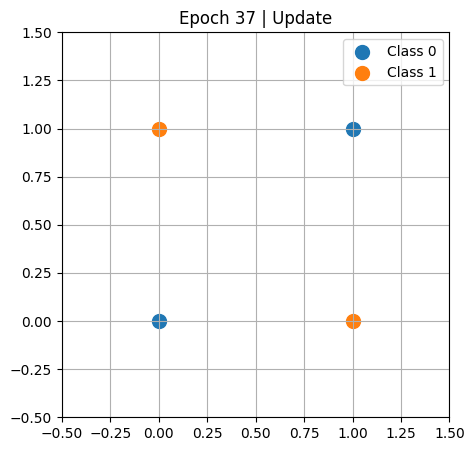

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


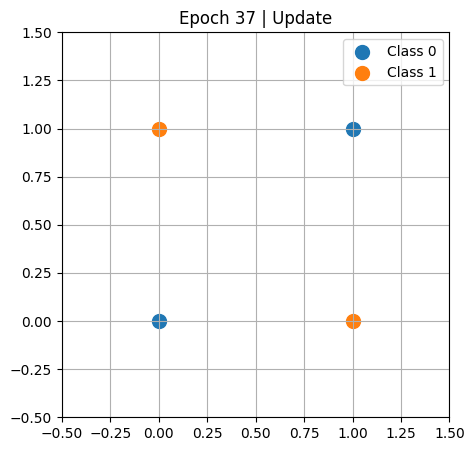

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 37/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


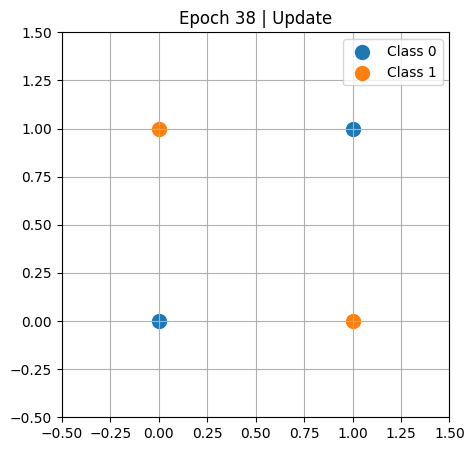

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


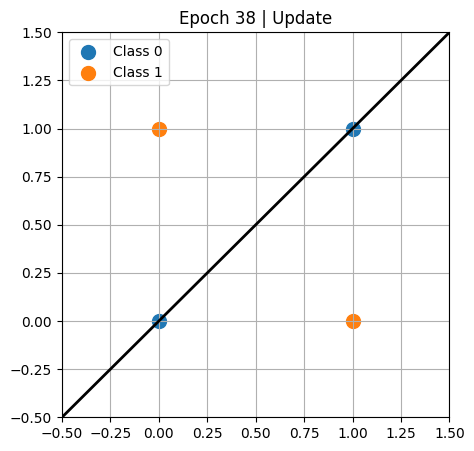

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


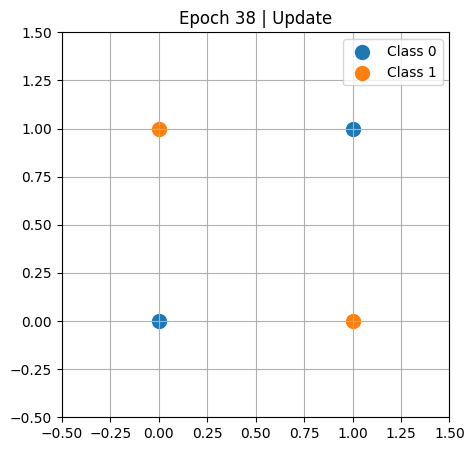

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


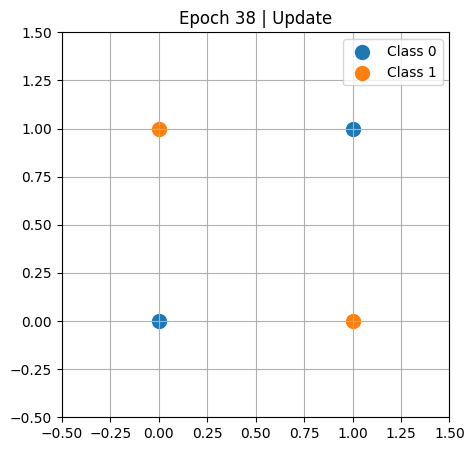

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 38/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


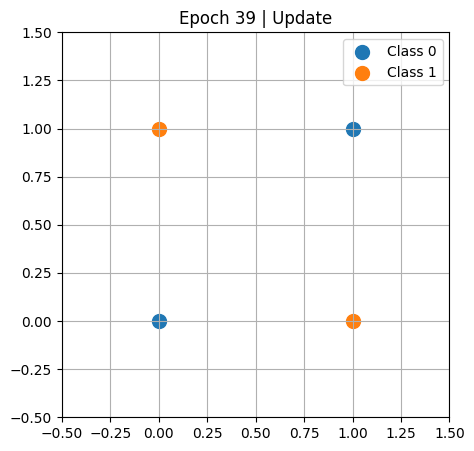

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


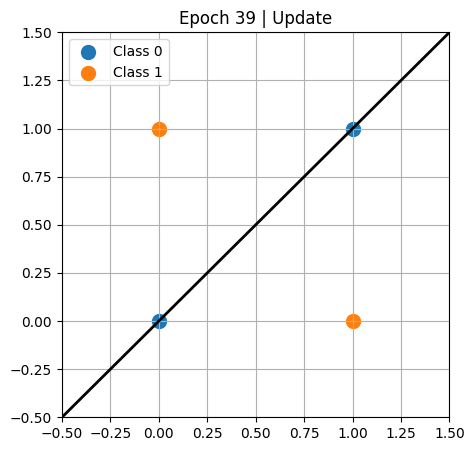

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


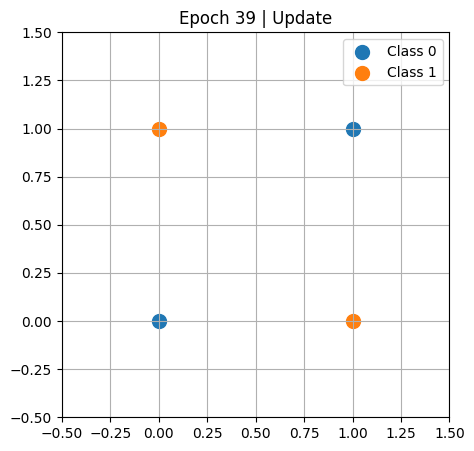

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


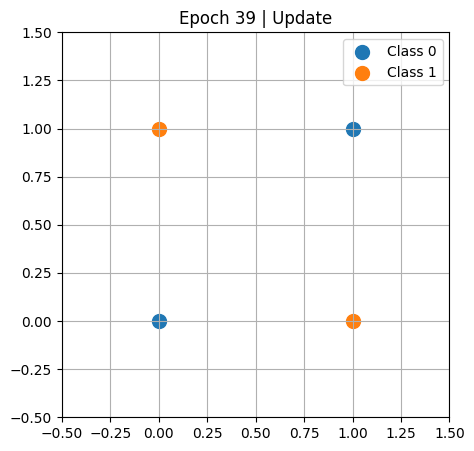

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 39/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


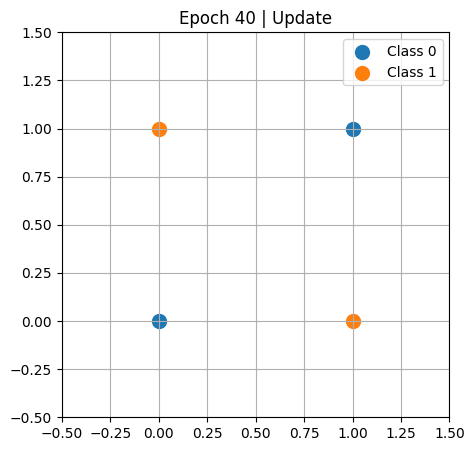

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


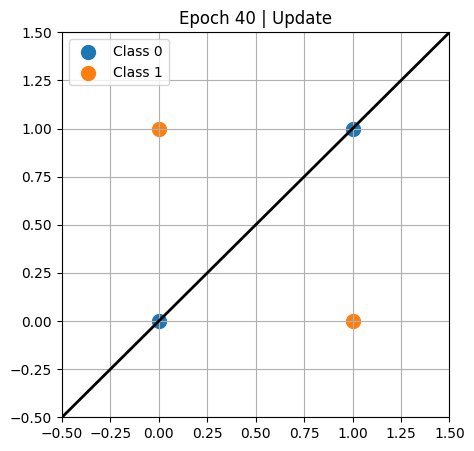

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


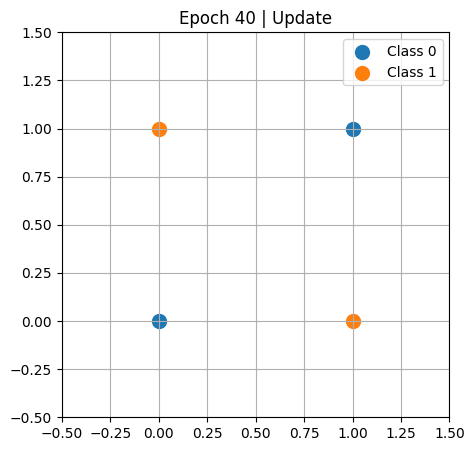

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


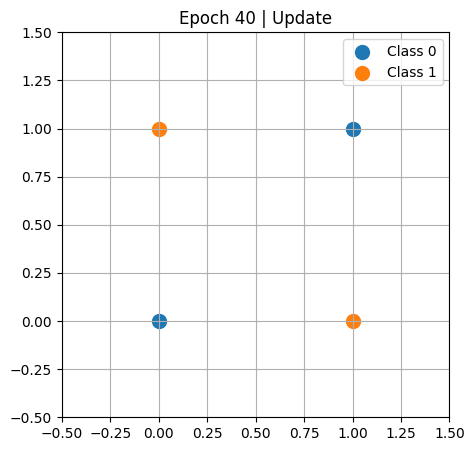

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 40/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


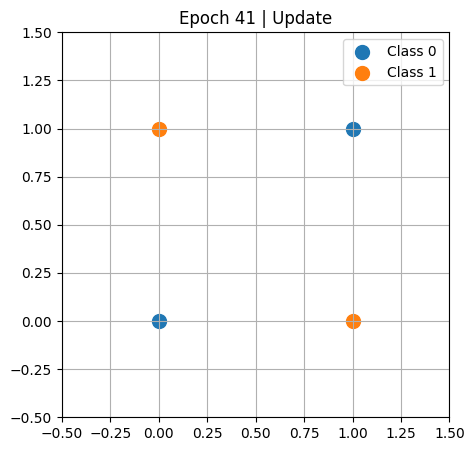

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


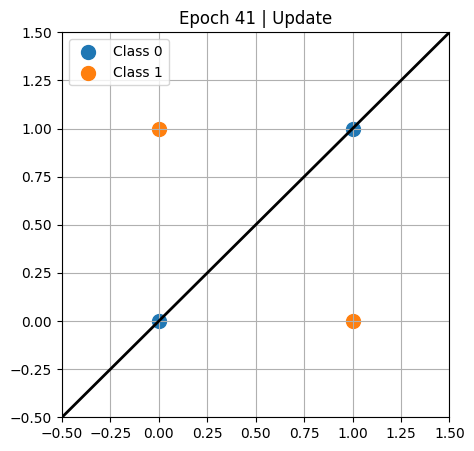

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


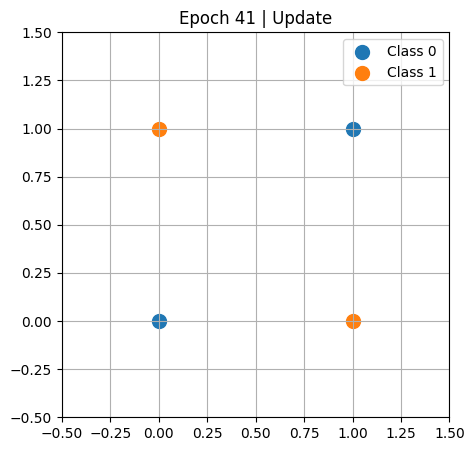

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


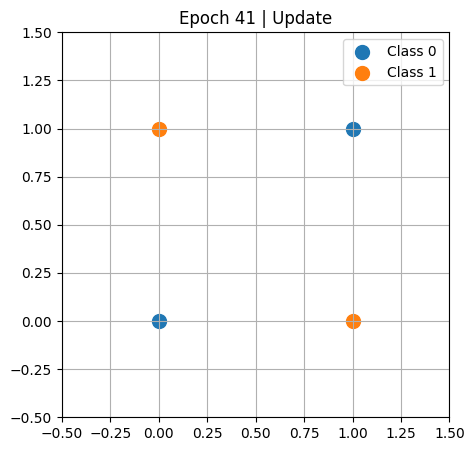

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 41/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


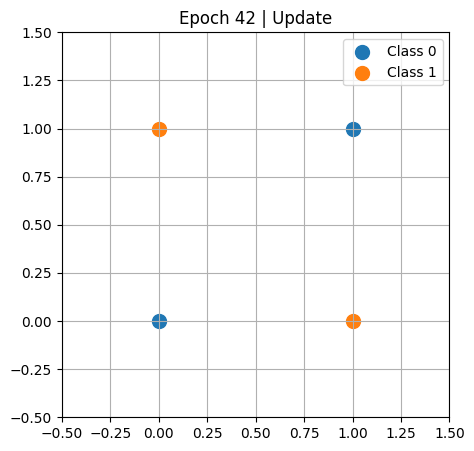

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


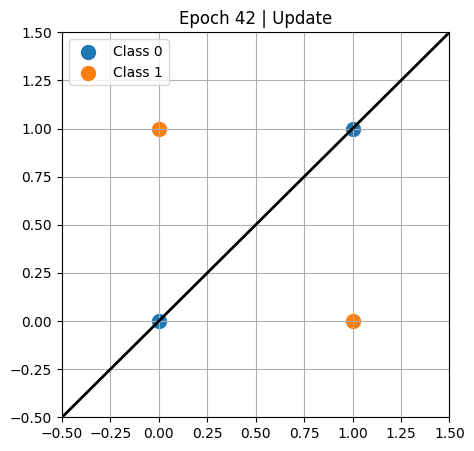

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


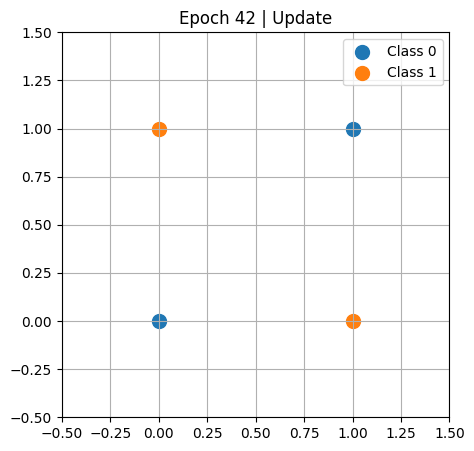

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


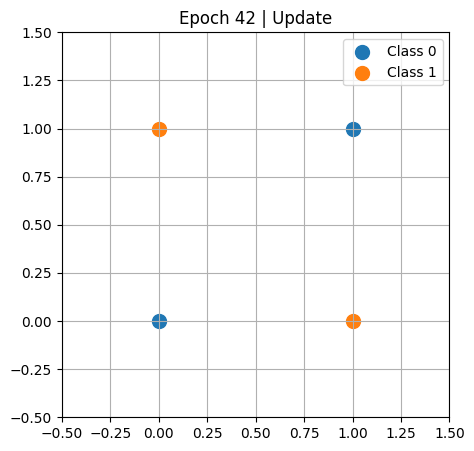

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 42/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


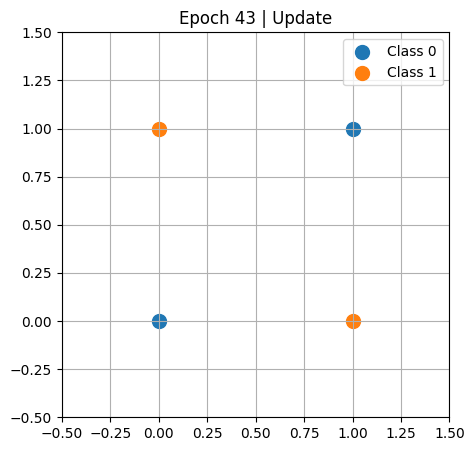

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


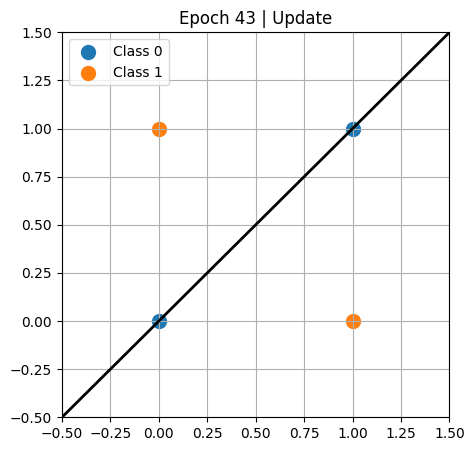

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


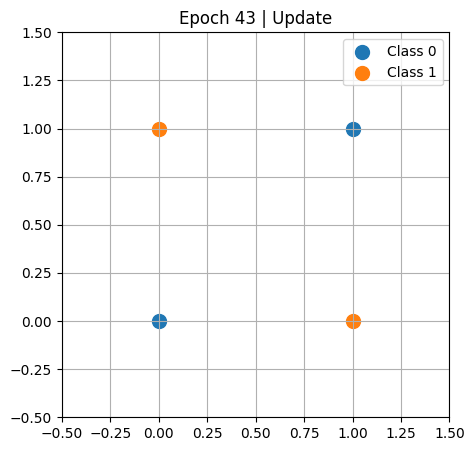

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


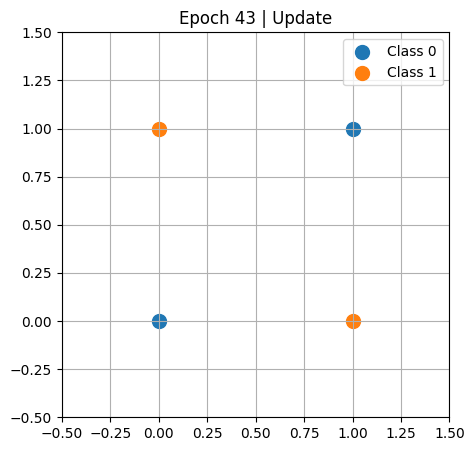

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 43/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


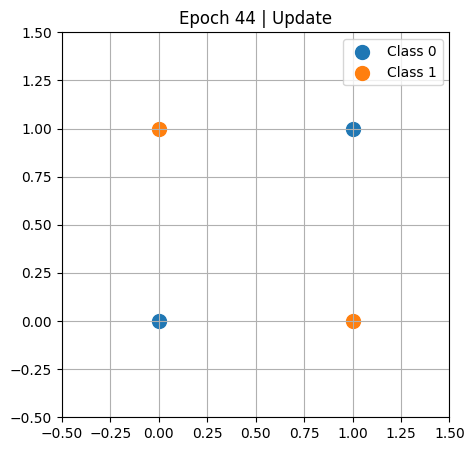

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


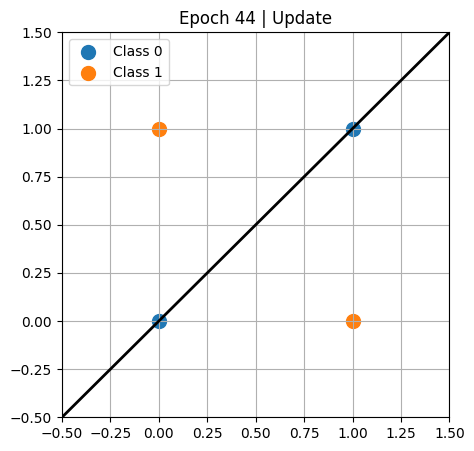

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


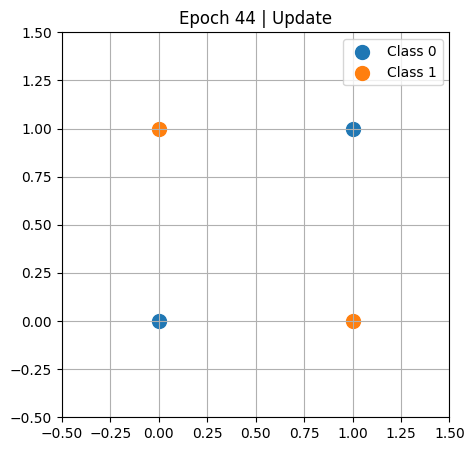

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


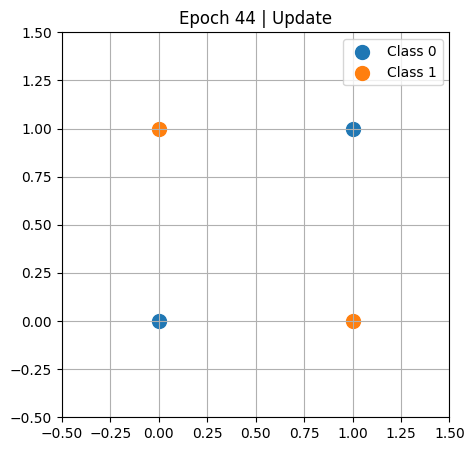

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 44/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


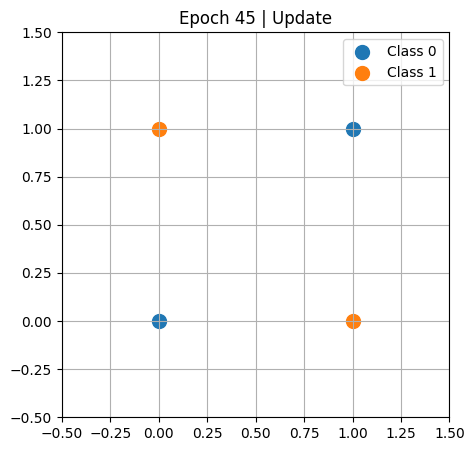

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


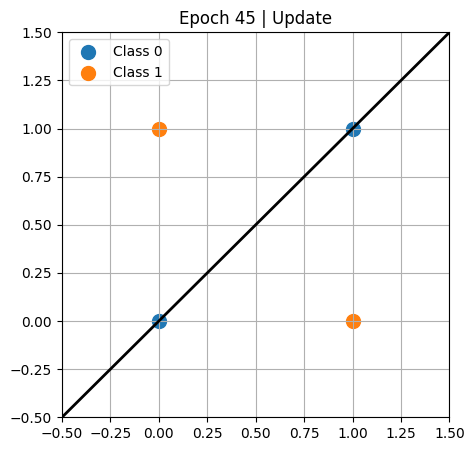

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


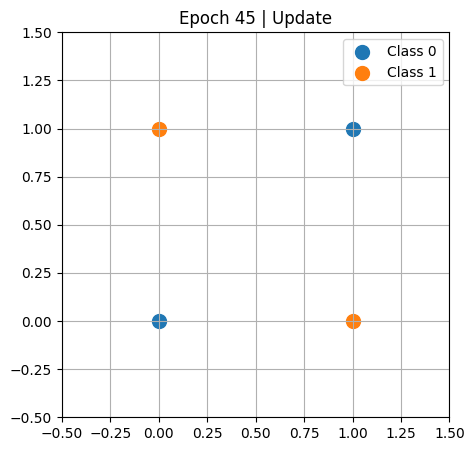

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


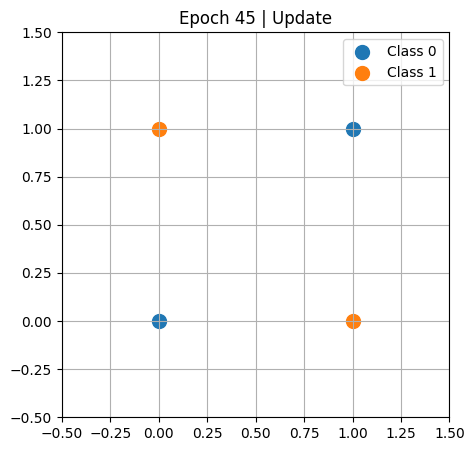

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 45/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


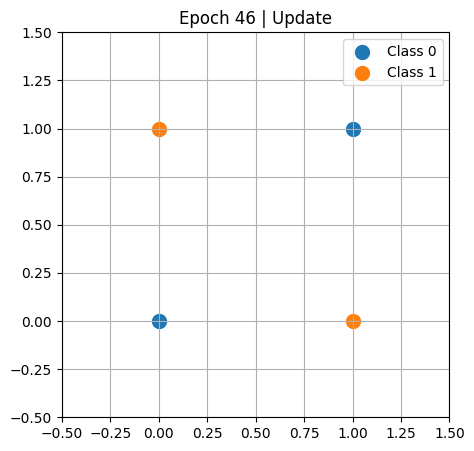

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


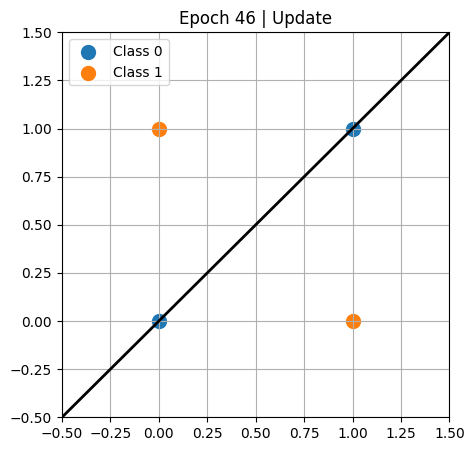

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


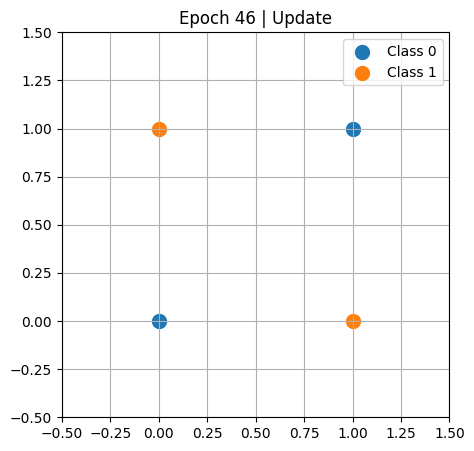

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


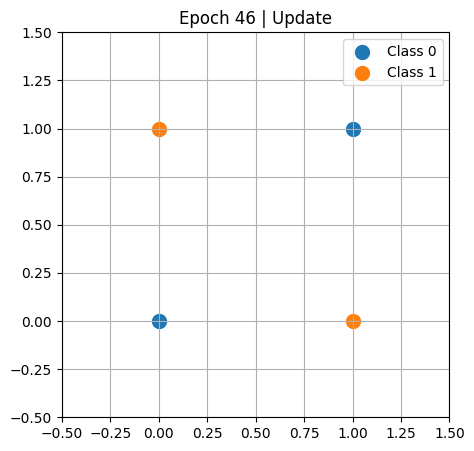

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 46/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


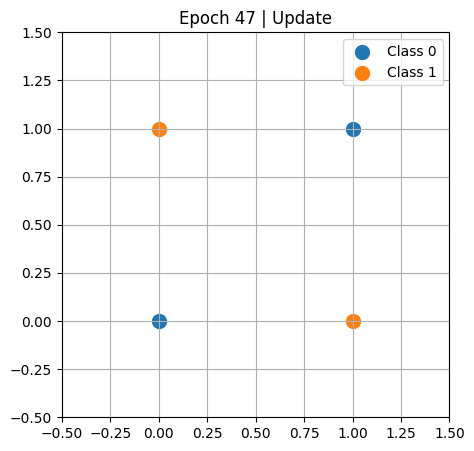

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


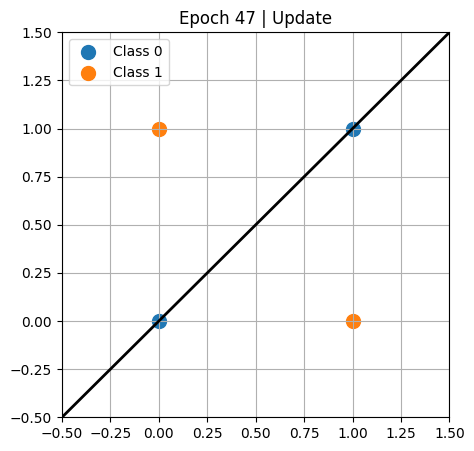

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


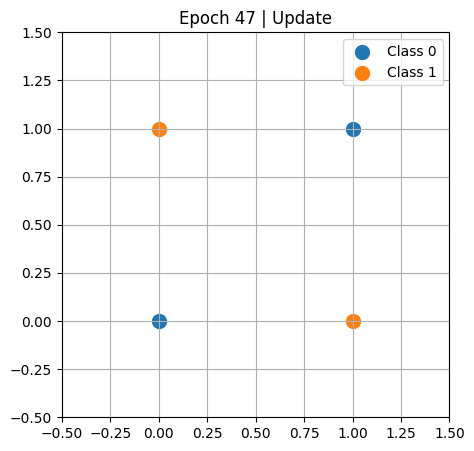

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


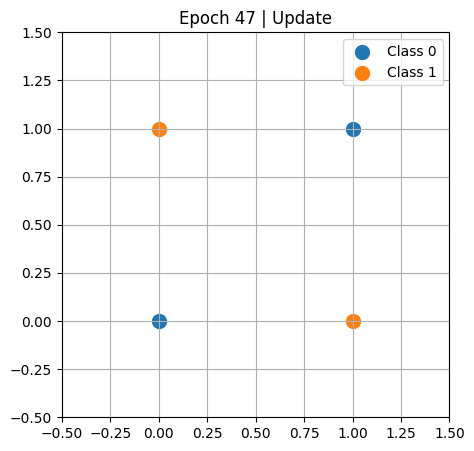

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 47/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


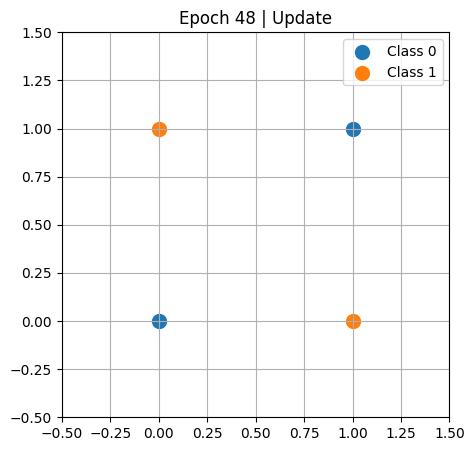

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


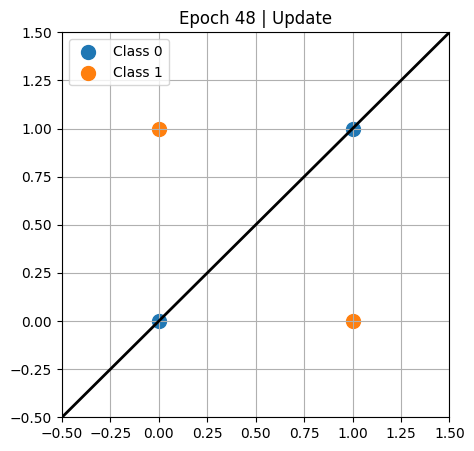

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


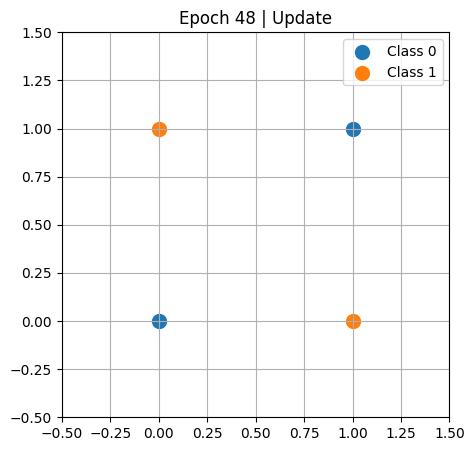

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


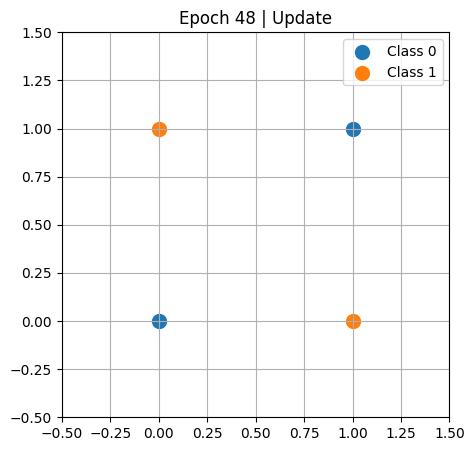

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 48/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


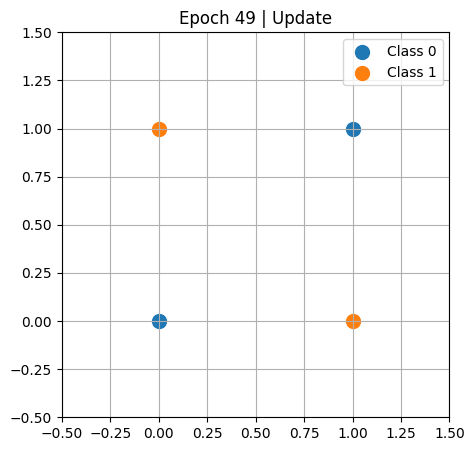

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


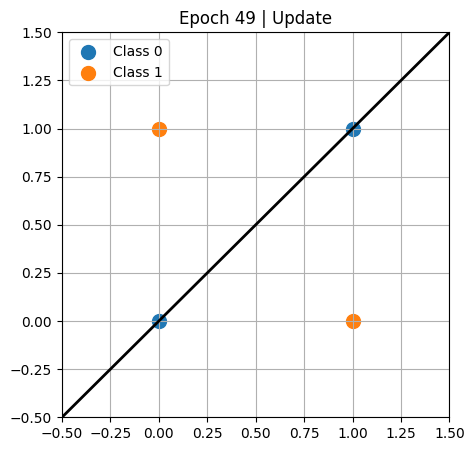

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


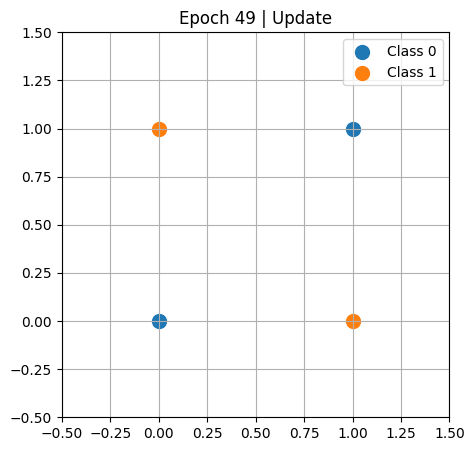

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


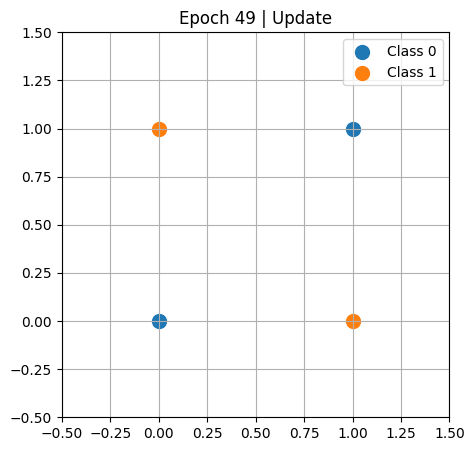

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 49/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


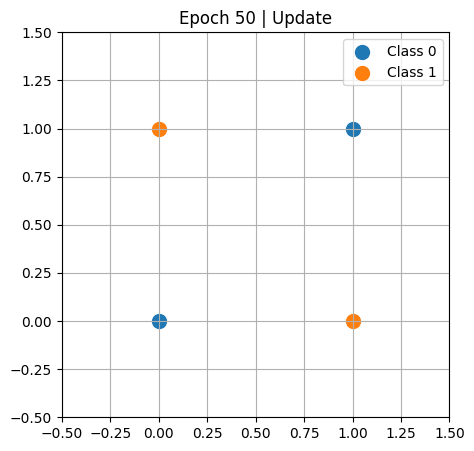

Updated Weights: [-0.01  0.  ]
Updated Bias   : -0.01


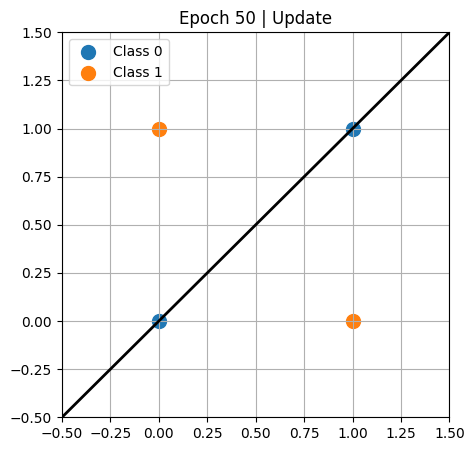

Updated Weights: [-0.01  0.01]
Updated Bias   : 0.0


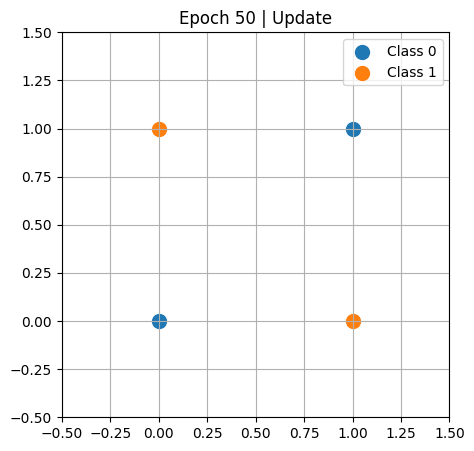

Updated Weights: [0.   0.01]
Updated Bias   : 0.01


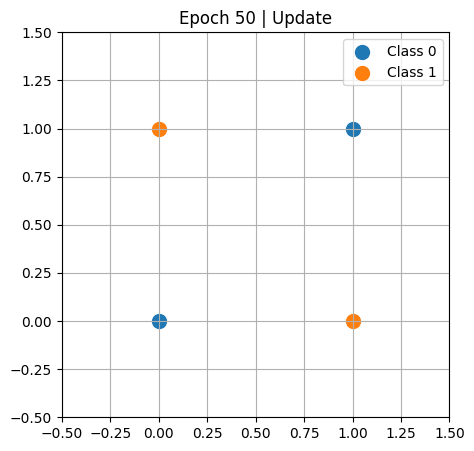

Updated Weights: [-0.01  0.  ]
Updated Bias   : 0.0
Epoch 50/50
Misclassified Samples : 4
Weights : [-0.01  0.  ]
Bias    : 0.0
--------------------------------------------------


In [66]:
#Perceptron for XOR Gate
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

perceptron = Perceptron(learning_rate=0.01, epochs=50)
perceptron.fit(X, y)

For XOR Gate, The perceptron will not converge as single layered perceptropn can only form linear decision boundaries
